<a href="https://colab.research.google.com/github/amathie5/PPS-Project-/blob/main/PPS_Project_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **I. Lot-sizing models**

## 1. Data and assumptions

Aurelius SA’s workshop is subject to fluctuating demand for its Heritage and Chronos models, with pronounced peaks in the months leading up to holidays and major exhibitions. In this context, the company must carefully balance setup costs, inventory holding costs, production costs, and operational constraints in order to minimize total costs over the planning horizon.

We begin by developing an uncapacitated lot-sizing model to determine the optimal production schedule over a 12-month horizon (January to December). This model relies on the following assumptions :
* no capacity constraints
* changing but known demand over time
* discrete periods (months in this case)
* instantaneous production within a period
* no security stocks

While this first model provides a useful theoretical benchmark, it does not fully reflect real-world operational limitations. We therefore extend the analysis by introducing a **capacitated lot-sizing model**, which incorporates production capacity constraints. In addition, production costs are assumed to increase during peak-demand periods.

More specifically, we assume that only unit production costs double during peak months, while setup and holding costs remain unchanged. This choice is justified by the nature of these cost components: peak periods typically require overtime labor, expedited procurement, or less efficient production processes, all of which directly impact unit production costs. In contrast, setup costs (e.g., machine configuration) and holding costs (e.g., warehousing) are largely structural and do not significantly fluctuate with short-term demand peaks.

This section presents the key parameters and data used to construct both models.

In [ ]:
from pulp import *
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.stats import norm
from google.colab import files
import io
from pylab import *
import seaborn as sns

In [ ]:
# Planning horizon
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
months_index = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
T = range(len(months))

# Demands
demands = [[150,140,200, 220, 250, 300, 270, 250, 320, 400, 420, 480],
           [120, 130, 150, 180, 210, 240, 230, 210, 260, 300, 310, 340]]

# Costs
p_list = [8000, 12000]
q_list = [20000, 25000]
h_list = [150, 200]
s0_list = [0, 0]



## 2. Problem Framing
The goal of this lot-sizing problem is to determine the optimal production quantities and timing for the Heritage and Chronos watch models over a 12-month horizon. The company must satisfy deterministic monthly demand while deciding:
* when to set up the production line for each product model
* the production quantity for each model in each month
* the inventory levels to carry over to the next month

The objective is to minimize the costs over the planning horizon while ensuring that all customer demand is met on time. The total cost includes:
* variable production costs
* fixed setup costs
* inventory holding costs


While the Uncapacitated Lot-Sizing (LS-U) model assumes unlimited resources, the Capacitated Lot-Sizing (LS-C) model introduces a maximum available time limit of 18000 hours per month. Furthermore, the capacitated model accounts for peak-time months (June, October, and December) where production costs are doubled.
### 2.1. Decision variables
For each product (i) and each month (t), we define the following decision variables:
* $X_{i,t}$: production quantity of product i in month t
* $S_{i,t}$: inventory level of product i at the end of month t
* $Y_{i,t}$: binary setup decision variable, equal to 1 if production of product i occurs in month t ($P_{i,t}$ > 0), and 0 otherwise
2.2. Objective Function
The objective is to minimize the total cost over the planning horizon, encompassing production, setup, and holding costs:
$$ \sum_{i=1}^{I} \sum_{t=1}^{T} (P_i X_{it} + Q_i Y_{it} + H_{i} S_{i,t})$$
where:
* $P_{i,t}$ represents the unit production cost of product i in month t. In the capacitated model (LS-C), this cost doubles during the peak-time months of June, October, and December.
* $Q_i$ represents the fixed setup cost incurred whenever a batch of product $i$ is produced ($Y_{i,t} = 1$).
* $H_i$ represents the monthly inventory holding cost charged per unit of product $i$ remaining in stock at the end of the month.
### 2.3. Constraints Framework
To ensure a feasible production plan, the models must respect several constraints:
* Inventory Balance: Monthly demand must be met using current production and previous inventory, with no backorders allowed. $$s_{i,t-1} + x_{it} = d_{it} + s_{it} \quad \forall i, t$$
* Setup Logic: Production $P_{i,t}$ can only be strictly positive if the corresponding setup variable $Y_{i,t}$ is activated ($Y_{i,t} = 1$). $$x_{it} \leq M y_{it} \quad \forall i, t$$
* Capacity Limit (LS-C only): The total time required for both setup and regular production across all models cannot exceed the available 18000 hours in any given month $t$.
$$\sum_{i} \alpha_{i} x_{i,t} + \sum_{i} \beta_{i} y_{i,t} \leq 18000 \quad \forall t$$

> Where :
> * $\alpha_{i}$ : Production time per unit for model $i$.
> * $\beta_{i}$ : Setup time per unit for model $i$

### 2.4. Managerial Interpretation
These models allow Aurelius SA to balance the critical trade-off between expensive setup costs and inventory holding costs. While the Uncapacitated model (LS-U) provides a theoretical cost baseline, the Capacitated model (LS-C) enables realistic planning by enforcing the 18,000 hour monthly limit.

Crucially, this framework empowers decision-makers to proactively minimize expenses, such as strategically pre-building inventory to avoid the double production costs during peak months (June, October, and December), ensuring customer demand is met at the lowest possible total cost.

In [ ]:
# Model sets and parameters are already defined in Section 1
n_months = len(months)

print("Planning horizon:", n_months, "months")
print("Total annual demand for Heritage:", sum(demands[0]))
print("Total annual demand for Heritage:", sum(demands[1]))

Planning horizon: 12 months
Total annual demand for Heritage: 3400
Total annual demand for Heritage: 2680


## 3. Uncapacitated Lot-Sizing model (LS-U)
Let us start with the uncapacitated model: as we are analyzing production for two products, we are going to use the multi-item LS-U model. This will allow to plan simultaneously the production of Heritage and Chronos watches.

In [ ]:
# Model definition
def multi_lsu(demands, p_list, q_list, h_list, s0_list):

    I = len(demands)
    T = len(demands[0])

    prob = LpProblem("Universal_Lot_Sizing_Model", LpMinimize)

    x = [[LpVariable(f"x_{i}_{t}", lowBound=0) for t in range(T)] for i in range(I)]
    s = [[LpVariable(f"s_{i}_{t}", lowBound=0) for t in range(T)] for i in range(I)]
    y = [[LpVariable(f"y_{i}_{t}", cat=LpBinary) for t in range(T)] for i in range(I)]

    costs = []
    for i in range(I):
        for t in range(T):
            costs.append(p_list[i] * x[i][t] + q_list[i] * y[i][t])
            prev_s = s0_list[i] if t == 0 else s[i][t-1]
            costs.append(h_list[i] * s[i][t])
    prob += lpSum(costs)

    for i in range(I):
        m_big = sum(demands[i])
        for t in range(T):
            prev_s = s0_list[i] if t == 0 else s[i][t-1]
            prob += prev_s + x[i][t] == demands[i][t] + s[i][t]
            prob += x[i][t] <= m_big * y[i][t]
    prob.solve()

   # Model execution and results analysis
    details_dict = {}
    analysis_dict = {}

    for i in range(I):
        details_dict[f"Product_{i+1}"] = pd.DataFrame({
            "Period": range(T),
            "Demand": demands[i],
            "Production": [value(x[i][t]) for t in range(T)],
            "Inventory": [value(s[i][t]) for t in range(T)],
            "Setup": [value(y[i][t]) for t in range(T)]
        })

        # Production period and Setup frequency
        production_periods = [t + 1 for t in range(T) if value(x[i][t]) > 0.01]
        setup_count = sum(1 for t in range(T) if value(y[i][t]) > 0.5)

        freq_text = f"1 setup every {round(T / setup_count, 1)} months" if setup_count > 0 else "No production"

        analysis_dict[f"Product_{i+1}"] = {
            "Produced_In_Periods": production_periods,
            "Total_Setups": setup_count,
            "Setup_Frequency": freq_text
        }

    return {
        "Status": LpStatus[prob.status],
        "Total_Cost": value(prob.objective),
        "Details": details_dict,
        "Analysis": analysis_dict
    }


result_lsu = multi_lsu(demands,
                       p_list,
                       q_list,
                       h_list,
                       s0_list)



/tmp/ipykernel_11333/1018358331.py:44: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  setup_count = sum(1 for t in range(T) if value(y[i][t]) > 0.5)


In [ ]:
# Displaying Heritage results
print(f"Status : {result_lsu["Status"]}")
print(f"Total cost (LS-U) : {result_lsu["Total_Cost"]} CHF\n")

print("---  Heritage Analysis (Product 1) ---")
print(result_lsu["Analysis"]["Product_1"])
print("\nHeritage production details :")
display(result_lsu["Details"]["Product_1"])

Status : Optimal
Total cost (LS-U) : 59900000.0 CHF

---  Heritage Analysis (Product 1) ---
{'Produced_In_Periods': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'Total_Setups': 12, 'Setup_Frequency': '1 setup every 1.0 months'}

Heritage production details :


,Period,Demand,Production,Inventory,Setup
0,0,150,150.0,0.0,1.0
1,1,140,140.0,0.0,1.0
2,2,200,200.0,0.0,1.0
3,3,220,220.0,0.0,1.0
4,4,250,250.0,0.0,1.0
5,5,300,300.0,0.0,1.0
6,6,270,270.0,0.0,1.0
7,7,250,250.0,0.0,1.0
8,8,320,320.0,0.0,1.0
9,9,400,400.0,0.0,1.0


In [ ]:
# Displaying Chronos results
print("\n--- Chronos Analysis (Product 2) ---")
print(result_lsu["Analysis"]["Product_2"])
print("\nChronos production details :")
# On utilise display() pour avoir le beau formatage Jupyter
display(result_lsu["Details"]["Product_2"])


--- Chronos Analysis (Product 2) ---
{'Produced_In_Periods': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'Total_Setups': 12, 'Setup_Frequency': '1 setup every 1.0 months'}

Chronos production details :


,Period,Demand,Production,Inventory,Setup
0,0,120,120.0,0.0,1.0
1,1,130,130.0,0.0,1.0
2,2,150,150.0,0.0,1.0
3,3,180,180.0,0.0,1.0
4,4,210,210.0,0.0,1.0
5,5,240,240.0,0.0,1.0
6,6,230,230.0,0.0,1.0
7,7,210,210.0,0.0,1.0
8,8,260,260.0,0.0,1.0
9,9,300,300.0,0.0,1.0


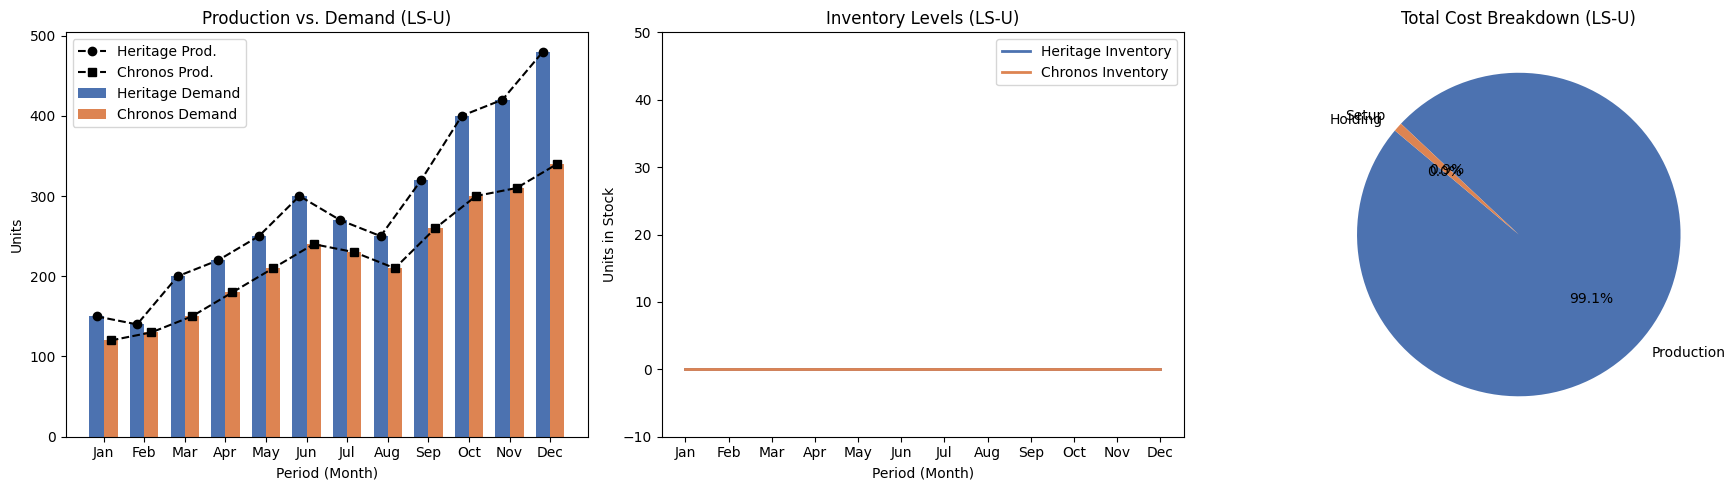

In [ ]:
## Visual Analysis

df_heritage = result_lsu["Details"]["Product_1"]
df_chronos = result_lsu["Details"]["Product_2"]
periods = df_heritage["Period"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Graph 1 : Production vs Demand
x = np.arange(len(periods))
width = 0.35
axes[0].bar(x - width/2, df_heritage["Demand"], width, label="Heritage Demand", color="#4C72B0")
axes[0].bar(x + width/2, df_chronos["Demand"], width, label="Chronos Demand", color="#DD8452")
axes[0].plot(x - width/2, df_heritage["Production"], marker="o", linestyle="--", color="black", label="Heritage Prod.")
axes[0].plot(x + width/2, df_chronos["Production"], marker="s", linestyle="--", color="black", label="Chronos Prod.")

axes[0].set_title("Production vs. Demand (LS-U)")
axes[0].set_xlabel("Period (Month)")
axes[0].set_ylabel("Units")
axes[0].set_xticks(ticks=months_index, labels=months)
axes[0].legend()

# --- Graph 2 : Inventory Levels
axes[1].step(periods, df_heritage["Inventory"], label="Heritage Inventory", where="mid", color="#4C72B0", linewidth=2)
axes[1].step(periods, df_chronos["Inventory"], label="Chronos Inventory", where="mid", color="#DD8452", linewidth=2)

axes[1].set_title("Inventory Levels (LS-U)")
axes[1].set_xlabel("Period (Month)")
axes[1].set_ylabel("Units in Stock")
axes[1].set_xticks(ticks=months_index, labels=months)
axes[1].set_ylim(-10, max(50, df_heritage["Inventory"].max() + 50))
axes[1].legend()

# --- Graph 3 : Cost Breakdown
prod_cost_h = (df_heritage["Production"] * p_list[0]).sum()
setup_cost_h = (df_heritage["Setup"] * q_list[0]).sum()
hold_cost_h = (df_heritage["Inventory"] * h_list[0]).sum()

prod_cost_c = (df_chronos["Production"] * p_list[1]).sum()
setup_cost_c = (df_chronos["Setup"] * q_list[1]).sum()
hold_cost_c = (df_chronos["Inventory"] * h_list[1]).sum()

total_prod = prod_cost_h + prod_cost_c
total_setup = setup_cost_h + setup_cost_c
total_hold = hold_cost_h + hold_cost_c

costs_lsu = [total_prod, total_setup, total_hold]
labels = ["Production", "Setup", "Holding"]
colors = ["#4C72B0", "#DD8452", "#55A868"]


axes[2].pie(costs_lsu, labels=labels, autopct="%1.1f%%", startangle=140, colors=colors)
axes[2].set_title("Total Cost Breakdown (LS-U)")

plt.tight_layout()
plt.show()

### 3.1. Interpretation of LS-U results
The Uncapacitated Lot-Sizing (LS-U) model adopts a strict Lot-for-Lot strategy. Production exactly matches demand each month, resulting in zero inventory and monthly setups for both products.

This occurs because holding costs are highly punitive compared to setup costs. For example, storing 140 Heritage units for one month costs 21,000 CHF, which exceeds the 20,000 CHF setup fee. Therefore, the solver minimizes total costs by producing just-in-time.

While mathematically optimal (Total Cost: 59,900,000 CHF), this baseline is unrealistic for operations. It ignores the 18,000-hour capacity limit and the 2x production costs during peak months (June, October, December). The upcoming Capacitated model (LS-C) will inevitably break this lot-for-lot pattern, forcing Aurelius SA to build anticipation inventory to smooth production, respect capacities, and avoid peak-time penalties.
## 4. Capacitated Lot-Sizing model (LS-C)
In order to be more realistic, we will now add the capacity constraint of 18,000 hrs/month to our model and take the peak-time costs for the months of June, October and December into account.

In [ ]:
# Parameters (specific to LS-C)
capacity_limit = 18000
prod_time = [8, 12]
setup_time = [25, 30]
peak_months = [5, 9, 11]
peak_mult = 2

In [ ]:
def multi_lsc(demands, p_list, q_list, h_list, s0_list, capacity_limit, prod_time, setup_time, peak_months, peak_mult):

    I = len(demands)
    T = len(demands[0])

    prob = LpProblem("Capacitated_Lot_Sizing_Model", LpMinimize)

    x = [[LpVariable(f"x_{i}_{t}", lowBound=0) for t in range(T)] for i in range(I)]
    s = [[LpVariable(f"s_{i}_{t}", lowBound=0) for t in range(T)] for i in range(I)]
    y = [[LpVariable(f"y_{i}_{t}", cat=LpBinary) for t in range(T)] for i in range(I)]

    costs = []
    for i in range(I):
        for t in range(T):
            # Peak-time costs
            current_p = p_list[i] * peak_mult if t in peak_months else p_list[i]
            costs.append(current_p * x[i][t] + q_list[i] * y[i][t])

            prev_s = s0_list[i] if t == 0 else s[i][t-1]
            costs.append(h_list[i] * s[i][t])
    prob += lpSum(costs)

    for i in range(I):
        m_big = sum(demands[i])
        for t in range(T):
            prev_s = s0_list[i] if t == 0 else s[i][t-1]
            prob += prev_s + x[i][t] == demands[i][t] + s[i][t]
            prob += x[i][t] <= m_big * y[i][t]

    # Capacity constraint
    for t in range(T):
        prob += lpSum(prod_time[i] * x[i][t] + setup_time[i] * y[i][t] for i in range(I)) <= capacity_limit

    prob.solve()

   # Model execution and results analysis
    details_dict = {}
    analysis_dict = {}

    for i in range(I):
        details_dict[f"Product_{i+1}"] = pd.DataFrame({
            "Period": range(T),
            "Demand": demands[i],
            "Production": [value(x[i][t]) for t in range(T)],
            "Inventory": [value(s[i][t]) for t in range(T)],
            "Setup": [value(y[i][t]) for t in range(T)]
        })

        # Production period and Setup frequency
        production_periods = [t + 1 for t in range(T) if value(x[i][t]) > 0.01]
        setup_count = sum(1 for t in range(T) if value(y[i][t]) > 0.5)

        freq_text = f"1 setup every {round(T / setup_count, 1)} months" if setup_count > 0 else "No production"

        analysis_dict[f"Product_{i+1}"] = {
            "Produced_In_Periods": production_periods,
            "Total_Setups": setup_count,
            "Setup_Frequency": freq_text
        }

    return {
        "Status": LpStatus[prob.status],
        "Total_Cost": value(prob.objective),
        "Details": details_dict,
        "Analysis": analysis_dict
    }


result_lsc = multi_lsc(
    demands=demands,
    p_list=p_list,
    q_list=q_list,
    h_list=h_list,
    s0_list=s0_list,
    capacity_limit=capacity_limit,
    prod_time=prod_time,
    setup_time=setup_time,
    peak_months=peak_months,
    peak_mult=peak_mult
)

/tmp/ipykernel_11333/3127197006.py:51: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  setup_count = sum(1 for t in range(T) if value(y[i][t]) > 0.5)


In [ ]:
# Displaying Heritage results
print(f"Status : {result_lsc["Status"]}")
print(f"Total cost (LS-C) : {result_lsc["Total_Cost"]} CHF\n")

print("---  Heritage Analysis (Product 1) ---")
print(result_lsc["Analysis"]["Product_1"])
print("\nHeritage production details :")
display(result_lsc["Details"]["Product_1"])

Status : Optimal
Total cost (LS-C) : 60118000.0 CHF

---  Heritage Analysis (Product 1) ---
{'Produced_In_Periods': [1, 2, 3, 4, 5, 7, 8, 9, 11], 'Total_Setups': 9, 'Setup_Frequency': '1 setup every 1.3 months'}

Heritage production details :


,Period,Demand,Production,Inventory,Setup
0,0,150,150.0,0.0,1.0
1,1,140,140.0,0.0,1.0
2,2,200,200.0,0.0,1.0
3,3,220,220.0,0.0,1.0
4,4,250,550.0,300.0,1.0
5,5,300,0.0,0.0,0.0
6,6,270,270.0,0.0,1.0
7,7,250,250.0,0.0,1.0
8,8,320,720.0,400.0,1.0
9,9,400,0.0,0.0,0.0


In [ ]:
# Displaying Chronos results
print("\n--- Chronos Analysis (Product 2) ---")
print(result_lsc["Analysis"]["Product_2"])
print("\nChronos production details :")
display(result_lsc["Details"]["Product_2"])


--- Chronos Analysis (Product 2) ---
{'Produced_In_Periods': [1, 2, 3, 4, 5, 7, 8, 9, 11], 'Total_Setups': 9, 'Setup_Frequency': '1 setup every 1.3 months'}

Chronos production details :


,Period,Demand,Production,Inventory,Setup
0,0,120,120.0,0.0,1.0
1,1,130,130.0,0.0,1.0
2,2,150,150.0,0.0,1.0
3,3,180,180.0,0.0,1.0
4,4,210,450.0,240.0,1.0
5,5,240,0.0,0.0,0.0
6,6,230,230.0,0.0,1.0
7,7,210,210.0,0.0,1.0
8,8,260,560.0,300.0,1.0
9,9,300,0.0,0.0,0.0


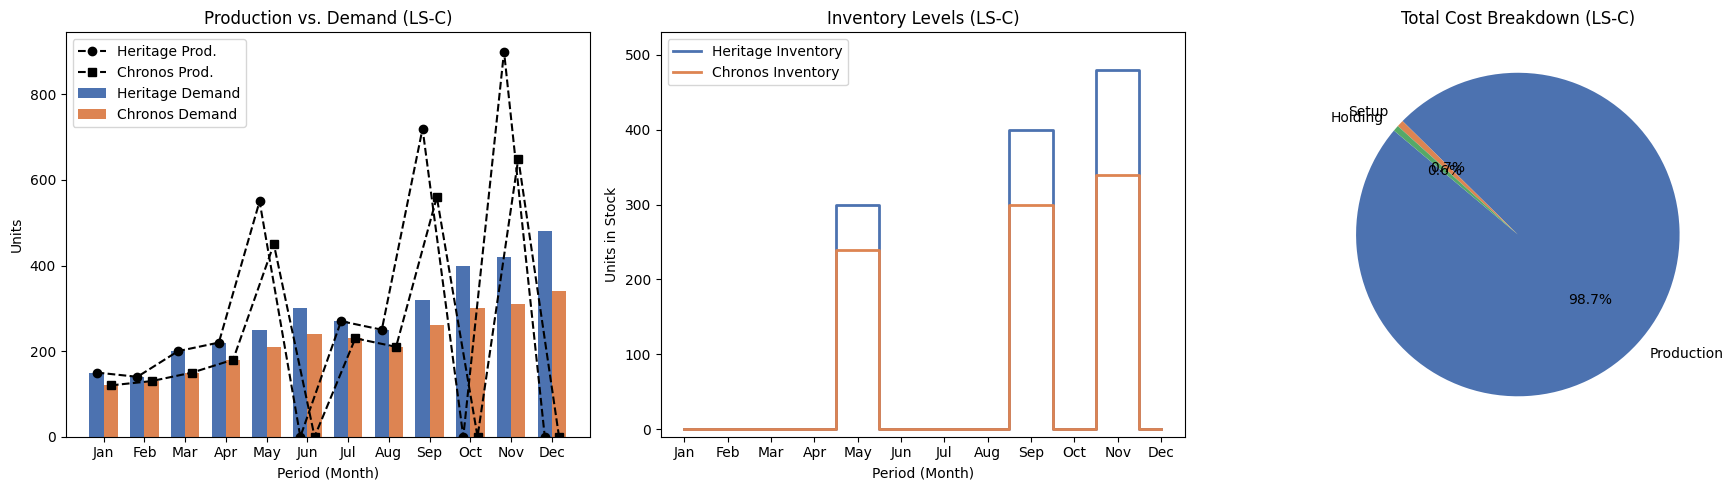

In [ ]:
## Visual Analysis

df_c_heritage = result_lsc["Details"]["Product_1"]
df_c_chronos = result_lsc["Details"]["Product_2"]
periods_c = df_c_heritage["Period"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Graph 1 : Production vs Demand
x_c = np.arange(len(periods_c))
width = 0.35
axes[0].bar(x_c - width/2, df_c_heritage["Demand"], width, label="Heritage Demand", color="#4C72B0")
axes[0].bar(x_c + width/2, df_c_chronos["Demand"], width, label="Chronos Demand", color="#DD8452")
axes[0].plot(x_c - width/2, df_c_heritage["Production"], marker="o", linestyle="--", color="black", label="Heritage Prod.")
axes[0].plot(x_c + width/2, df_c_chronos["Production"], marker="s", linestyle="--", color="black", label="Chronos Prod.")

axes[0].set_title("Production vs. Demand (LS-C)")
axes[0].set_xlabel("Period (Month)")
axes[0].set_ylabel("Units")
axes[0].set_xticks(ticks=months_index, labels=months)
axes[0].legend()

# --- Graph 2 : Inventory Levels
axes[1].step(periods_c, df_c_heritage["Inventory"], label="Heritage Inventory", where="mid", color="#4C72B0", linewidth=2)
axes[1].step(periods_c, df_c_chronos["Inventory"], label="Chronos Inventory", where="mid", color="#DD8452", linewidth=2)

axes[1].set_title("Inventory Levels (LS-C)")
axes[1].set_xlabel("Period (Month)")
axes[1].set_ylabel("Units in Stock")
axes[1].set_xticks(ticks=months_index, labels=months)
axes[1].set_ylim(-10, max(50, df_c_heritage["Inventory"].max() + 50))
axes[1].legend()

# --- Graph 3 : Cost Breakdown
prod_cost_h_c = (df_c_heritage["Production"] * p_list[0]).sum()
setup_cost_h_c = (df_c_heritage["Setup"] * q_list[0]).sum()
hold_cost_h_c = (df_c_heritage["Inventory"] * h_list[0]).sum()

prod_cost_c_c = (df_c_chronos["Production"] * p_list[1]).sum()
setup_cost_c_c = (df_c_chronos["Setup"] * q_list[1]).sum()
hold_cost_c_c = (df_c_chronos["Inventory"] * h_list[1]).sum()

total_prod_c = prod_cost_h_c + prod_cost_c_c
total_setup_c = setup_cost_h_c + setup_cost_c_c
total_hold_c = hold_cost_h_c + hold_cost_c_c

costs_lsc = [total_prod_c, total_setup_c, total_hold_c]

axes[2].pie(costs_lsc, labels=labels, autopct="%1.1f%%", startangle=140, colors=colors)
axes[2].set_title("Total Cost Breakdown (LS-C)")

plt.tight_layout()
plt.show()


### 4.1 Interpretation of LS-C results and comparison with LS-U

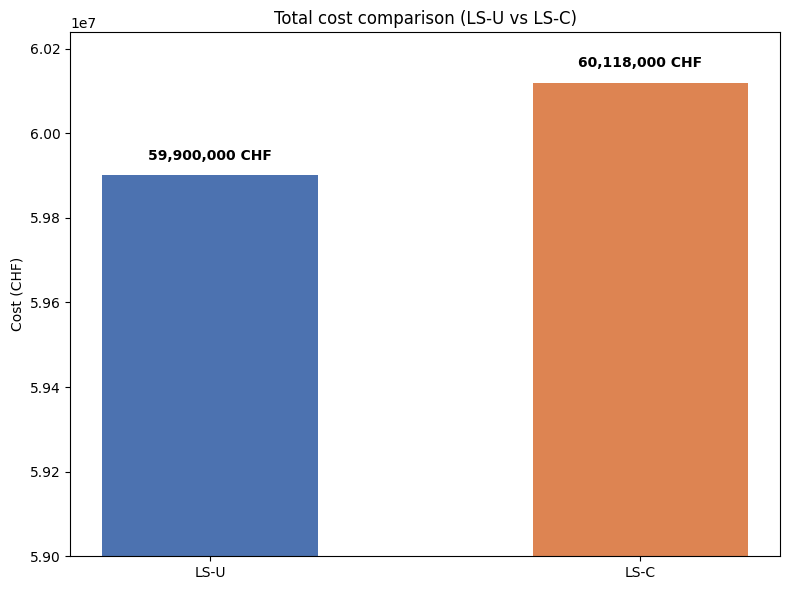

In [ ]:
cost_lsu = result_lsu["Total_Cost"]
cost_lsc = result_lsc["Total_Cost"]

fig, ax = plt.subplots(figsize=(8, 6))

# --- Graph : Total cost comparison ---
bars = ax.bar(
    ["LS-U", "LS-C"],
    [cost_lsu, cost_lsc],
    color=["#4C72B0", "#DD8452"],
    width=0.5
)

ax.set_title("Total cost comparison (LS-U vs LS-C)")
ax.set_ylabel("Cost (CHF)")

ax.set_ylim(bottom=59000000, top=max(cost_lsu, cost_lsc) * 1.002)

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.0,
        yval + (yval * 0.0005),
        f"{yval:,.0f} CHF",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

By adding constraints to our model, we observe a strategic shift to anticipation inventory. Indeed, the introduction of capacity limits and peak-month penalties fundamentally changes the production strategy. The strict lot-for-lot approach observed in the LS-U model is no longer viable. Instead, the LS-C model completely halts production for both Heritage and Chronos during the expensive peak months of June (Period 6), October (Period 10), and December (Period 12).

To meet demand during these zero-production peak months, the model strategically pre-builds inventory. For example, looking at the Heritage model in Period 5 (May), the solver orders a massive production batch of 550 units. This covers both the current demand for May (250 units) and the upcoming demand for June (300 units). These 300 units are kept in stock, incurring a holding cost of 45,000 CHF (300 units * 150 CHF/unit). However, this is drastically cheaper than paying the 2x production penalty in June, which would have cost an extra 2,400,000 CHF (300 units * 8,000 CHF penalty).

The total cost has slightly increased from 59,900,000 CHF for the uncapacitated baseline to 60,118,000 CHF. This difference of 218,000 CHF represents the necessary holding costs Aurelius SA must absorb to optimally smooth out production, respect the strict 18,000-hour monthly capacity limit, and completely bypass the severe financial penalties of the peak season.
# **II. Material Requirement Planning Model**
## 1. Data and assumptions
Each watch requires the assembly of multiple components with different lead times. Therefore, it is crucial for Aurelius SA's production plan to account for these lead times and component availability to avoid stockouts and minimize excess inventory. To achieve this, we will build an MRP (Material Requirements Planning) model linking finished product demand to component procurement, while integrating the bill of materials (BOM) and lead times.

For the development of this model, we formulate the following assumptions:
* There are no capacity restrictions on the assembly line.
* There is a known initial inventory for each component.
* Components have lead times ranging from 1 to 2 months.
* No security stocks

This section presents the key data and parameters used to build the MRP model.

In [ ]:
# List of components
components = [
    "3235 Movement",
    "Oystersteel Case",
    "Sapphire Crystal",
    "Jubilee Bracelet",
    "Diamond Marker",
    "Lubricant Oil",
    "Gold Crown"
]

# Bill of Materials (BOM): component units per watch model
# Lubricant oil is counted in 10g units (1 watch = 1 unit of 10g)
bom = {
    "3235 Movement": {"Heritage": 1, "Chronos": 1},
    "Oystersteel Case": {"Heritage": 1, "Chronos": 1},
    "Sapphire Crystal": {"Heritage": 1, "Chronos": 1},
    "Jubilee Bracelet": {"Heritage": 1, "Chronos": 0},
    "Diamond Marker": {"Heritage": 0, "Chronos": 8},
    "Lubricant Oil": {"Heritage": 1, "Chronos": 1},
    "Gold Crown": {"Heritage": 1, "Chronos": 0}
}

# Lead times in months for each component
lead_times = {
    "3235 Movement": 2,
    "Oystersteel Case": 1,
    "Sapphire Crystal": 1,
    "Jubilee Bracelet": 2,
    "Diamond Marker": 2,
    "Lubricant Oil": 1,
    "Gold Crown": 1
}

# Initial inventory
initial_inventory = {
    "3235 Movement": 900,
    "Oystersteel Case": 550,
    "Sapphire Crystal": 550,
    "Jubilee Bracelet": 500,
    "Diamond Marker": 3200,
    "Lubricant Oil": 550,   #550 units of 10g
    "Gold Crown": 300
}

# Production costs per unit in CHF
production_costs = {
    "3235 Movement": 6500,
    "Oystersteel Case": 2000,
    "Sapphire Crystal": 1500,
    "Jubilee Bracelet": 1800,
    "Diamond Marker": 400,
    "Lubricant Oil": 100,
    "Gold Crown": 600
}

# Holding costs per unit per month in CHF
holding_costs = {
    "3235 Movement": 12,
    "Oystersteel Case": 60,
    "Sapphire Crystal": 80,
    "Jubilee Bracelet": 40,
    "Diamond Marker": 25,
    "Lubricant Oil": 3,
    "Gold Crown": 20
}

# Setup costs per batch in CHF
setup_costs = {
    "3235 Movement": 80000,
    "Oystersteel Case": 50000,
    "Sapphire Crystal": 50000,
    "Jubilee Bracelet": 35000,
    "Diamond Marker": 20000,
    "Lubricant Oil": 10000,
    "Gold Crown": 25000
}

#For now we are going to consider no external demand for Oystersteel Cases
external_demand_oystersteel = [0] * 12



## 2. Problem Framing
Aurelius SA faces a complex production and inventory management challenge for its Heritage and Chronos watch models over a 12-month planning horizon. The objective is to design a Material Requirements Planning (MRP) system that mathematically minimizes total operational costs while ensuring component availability for final assembly.

The core complexity lies in the dual demand for Oystersteel Cases: Aurelius must fulfill internal requirements for its own watch production while simultaneously satisfying external demand from business partners.

Therefore, the key decisions to be determined by the algorithm are:
* Lot-Sizing and Timing: Calculating the optimal quantities and schedules for each of the 7 components, strictly respecting the 1 to 2-month lead times and the Bill of Materials (BOM) dependencies.
* Inventory Management: Tracking initial inventories and calculating projected on-hand stock across all periods to avoid shortages.
* Component Allocation: Determining the exact distribution of Oystersteel Cases between internal manufacturing needs and external demand.
### 2.1. Decision variables and objective function
Because this model serves as a natural extension of the preceding lot-sizing model, the fundamental decision variables (production quantities, inventory levels, and setups) remain consistent. Furthermore, the objective function retains its original formulation, aiming to minimize the total cost.
### 2.2. Constraints Framework
The constraints framework closely mirrors the lot-sizing model, with crucial adaptations to account for multi-level component dependencies:
Inventory Balance: Unlike finished goods, components face both independent (external) and dependent (internal) demand. The inventory balance equation incorporates this dependent demand, calculated as the total quantity of component $i$ required to produce all parent items $j$ in period $t$. Here, $r_{ij}$ represents the Bill of Materials usage rate (units of $i$ per parent $j$), and $x_{jt}$ is the planned production of the parent. $$s_{it-1} + x_{it} = d_{it} + \sum_{j \in P(i)} r_{ij}x_{jt} + s_{it}$$
* Setup Logic:  $$x_{it} \leq M y_{it} \quad \forall i, t$$
* Initial inventory : The starting point for the inventory balance equation needs to be define to ensure that the stock at the beginning of the first period is linked to the data. $$s_{i0} = initial_{i} $$

### 2.3. Managerial Interpretation
The MRP model represents an indispensable operational tool for Aurelius SA, transitioning the company from high-level finished-product planning (LS-U and LS-C) to a highly actionable supply chain strategy.

From a managerial perspective, the outputs of this model drive three major business benefits:
* Proactive Risk Mitigation: Rather than reacting to shortages, managers receive a precise procurement schedule. This allows the purchasing and production teams to synchronize their efforts perfectly, eliminating factory downtime while keeping working capital tied up in inventory to an absolute minimum.
* Strategic Sales Arbitrage: The model provides a quantitative resolution to the Oystersteel conflict. It gives managers a clear financial justification to accept or reject external client orders, ensuring that B2B sales never jeopardize the company's internal watch assembly.
* Financial Visibility: By dynamically balancing massive setup fees against monthly holding costs, the MRP establishes the most cost-efficient baseline for the entire year, directly protecting and maximizing Aurelius SA's profit margins.

In [ ]:
# Model sets and parameters are already defined in Section 1
n_comp = len(components)

print("Number of components:", n_comp)

Number of components: 7


## 3. Material Requirement Planning model (MRP)
### 3.1. Sequential MRP
As a first step, we will use the optimized production schedule derived from the Capacitated Lot-Sizing (LS-C) model as a fixed baseline to determine the procurement and production plan for all components.

In [ ]:
mps_heritage = result_lsc["Details"]["Product_1"]["Production"].tolist()
mps_chronos = result_lsc["Details"]["Product_2"]["Production"].tolist()

In [ ]:
def mrp_sequential(mps_heritage, mps_chronos, external_demand_oystersteel,
                   components, bom, lead_times, initial_inventory,
                   production_costs, holding_costs, setup_costs, ext_d=True):

    T = len(mps_heritage)
    prob = LpProblem("MRP_Sequential", LpMinimize)

    # Decision variables
    x = {i: [LpVariable(f"x_{i}_{t}", lowBound=0) for t in range(T)] for i in components}
    s = {i: [LpVariable(f"s_{i}_{t}", lowBound=0) for t in range(T)] for i in components}
    y = {i: [LpVariable(f"y_{i}_{t}", cat=LpBinary) for t in range(T)] for i in components}

    tot_demand = {i: [] for i in components}
    m_comp = {}

    # Total demand per component
    for i in components:
        for t in range(T):
            dep_req = bom[i]["Heritage"] * mps_heritage[t] + bom[i]["Chronos"] * mps_chronos[t]
            if ext_d==False:
              ext_req = 0
            else:
              ext_req = external_demand_oystersteel[t] if i == "Oystersteel Case" else 0
            tot_demand[i].append(dep_req + ext_req)
        m_comp[i] = sum(tot_demand[i]) + 1000

    # Objective function
    prob += lpSum(production_costs[i] * x[i][t] + setup_costs[i] * y[i][t] + holding_costs[i] * s[i][t]
                  for i in components for t in range(T))

    # Constraints
    for i in components:
        lt = lead_times[i]
        for t in range(T):
            prev_s = initial_inventory[i] if t == 0 else s[i][t-1]
            receipts = x[i][t - lt] if t >= lt else 0
            prob += prev_s + receipts == tot_demand[i][t] + s[i][t]
            prob += x[i][t] <= m_comp[i] * y[i][t]

    # solution
    prob.solve(PULP_CBC_CMD(msg=0))

    results = {
        "Status": LpStatus[prob.status],
        "Total_Cost": value(prob.objective),
        "Details": {}
    }

    for i in components:
        import pandas as pd
        df = pd.DataFrame({
            "Month": range(T),
            "Demand": tot_demand[i],
            "Production_start": [value(x[i][t]) for t in range(T)],
            "Final_inv": [value(s[i][t]) for t in range(T)],
            "Setup": [value(y[i][t]) for t in range(T)]
        })
        results["Details"][i] = df

    return results


Below is the optimized component production plan, which accounts exclusively for internal demand and builds upon the finished product optimization solved using the LS-C model.

In [ ]:
result_mrp_seq = mrp_sequential(
    mps_heritage, mps_chronos, external_demand_oystersteel,
    components, bom, lead_times, initial_inventory,
    production_costs, holding_costs, setup_costs, ext_d=False
)

print(f"Status : {result_mrp_seq['Status']}")
print(f"Total cost of components supply : {result_mrp_seq['Total_Cost']:,.0f} CHF")

components_to_display = [
    "3235 Movement",
    "Oystersteel Case",
    "Sapphire Crystal",
    "Jubilee Bracelet",
    "Diamond Marker",
    "Lubricant Oil",
    "Gold Crown"
]

for component in components_to_display:
    print(f"\n--- Detailed plan for {component} ---")
    display(result_mrp_seq["Details"][component])

Status : Optimal
Total cost of components supply : 69,457,010 CHF

--- Detailed plan for 3235 Movement ---


,Month,Demand,Production_start,Final_inv,Setup
0,0,270.0,0.0,630.0,0.0
1,1,270.0,2350.0,360.0,1.0
2,2,350.0,0.0,10.0,0.0
3,3,400.0,0.0,1960.0,0.0
4,4,1000.0,0.0,960.0,0.0
5,5,0.0,0.0,960.0,0.0
6,6,500.0,2830.0,460.0,1.0
7,7,460.0,0.0,0.0,0.0
8,8,1280.0,0.0,1550.0,0.0
9,9,0.0,0.0,1550.0,0.0



--- Detailed plan for Oystersteel Case ---


,Month,Demand,Production_start,Final_inv,Setup
0,0,270.0,0.0,280.0,0.0
1,1,270.0,740.0,10.0,1.0
2,2,350.0,0.0,400.0,0.0
3,3,400.0,1000.0,0.0,1.0
4,4,1000.0,0.0,0.0,0.0
5,5,0.0,960.0,0.0,1.0
6,6,500.0,0.0,460.0,0.0
7,7,460.0,1280.0,0.0,1.0
8,8,1280.0,0.0,0.0,0.0
9,9,0.0,1550.0,0.0,1.0



--- Detailed plan for Sapphire Crystal ---


...

,Month,Demand,Production_start,Final_inv,Setup
0,0,960.0,0.0,2240.0,0.0
1,1,1040.0,1440.0,1200.0,1.0
2,2,1200.0,3600.0,0.0,1.0
3,3,1440.0,0.0,0.0,0.0
4,4,3600.0,1840.0,0.0,1.0
5,5,0.0,1680.0,0.0,1.0
6,6,1840.0,4480.0,0.0,1.0
7,7,1680.0,0.0,0.0,0.0
8,8,4480.0,5200.0,0.0,1.0
9,9,0.0,0.0,0.0,0.0



--- Detailed plan for Lubricant Oil ---


,Month,Demand,Production_start,Final_inv,Setup
0,0,270.0,0.0,280.0,0.0
1,1,270.0,1740.0,10.0,1.0
2,2,350.0,0.0,1400.0,0.0
3,3,400.0,0.0,1000.0,0.0
4,4,1000.0,0.0,0.0,0.0
5,5,0.0,2240.0,0.0,1.0
6,6,500.0,0.0,1740.0,0.0
7,7,460.0,0.0,1280.0,0.0
8,8,1280.0,0.0,0.0,0.0
9,9,0.0,1550.0,0.0,1.0



--- Detailed plan for Gold Crown ---


,Month,Demand,Production_start,Final_inv,Setup
0,0,150.0,0.0,150.0,0.0
1,1,140.0,410.0,10.0,1.0
2,2,200.0,0.0,220.0,0.0
3,3,220.0,820.0,0.0,1.0
4,4,550.0,0.0,270.0,0.0
5,5,0.0,0.0,270.0,0.0
6,6,270.0,970.0,0.0,1.0
7,7,250.0,0.0,720.0,0.0
8,8,720.0,0.0,0.0,0.0
9,9,0.0,900.0,0.0,1.0


### 3. Integrated MRP


To overcome the rigid limitations of the sequential approach, we now implement an Integrated MRP model. Instead of treating watch production and component procurement as isolated steps, this mathematical formulation optimizes both simultaneously. By allowing the algorithm to dynamically synchronize final assembly schedules with component batching, we achieve the absolute minimum total supply chain cost for Aurelius SA.

At first, we will optimize the production plan without considering the external demand for Oystersteel Case.

In [ ]:
#Dictionary for the time constraints
unit_hours= {"Heritage": 8, "Chronos": 12}
setup_hours = {"Heritage": 25, "Chronos": 30}

In [ ]:
def mrp_integrated(demands, external_demand_oystersteel, components, bom, lead_times, initial_inventory,
                   production_costs, holding_costs, setup_costs, s0_list, p_list, h_list, q_list,
                   capacity_limit, unit_hours, setup_hours, peak_months, peak_mult, ext_d=True):

    watch_demands = {"Heritage": demands[0], "Chronos": demands[1]}
    watch_init_inv = {"Heritage": s0_list[0], "Chronos": s0_list[1]}
    watch_prod_costs = {"Heritage": p_list[0], "Chronos": p_list[1]}
    watch_hold_costs = {"Heritage": h_list[0], "Chronos": h_list[1]}
    watch_setup_costs = {"Heritage": q_list[0], "Chronos": q_list[1]}

    T = len(watch_demands["Heritage"])
    watches = ["Heritage", "Chronos"]

    prob = LpProblem("MRP_Integrated_Global", LpMinimize)

    # Decision variables watches
    xw = {w: [LpVariable(f"xw_{w}_{t}", lowBound=0) for t in range(T)] for w in watches}
    sw = {w: [LpVariable(f"sw_{w}_{t}", lowBound=0) for t in range(T)] for w in watches}
    yw = {w: [LpVariable(f"yw_{w}_{t}", cat=LpBinary) for t in range(T)] for w in watches}

    # Decision variables components
    xc = {i: [LpVariable(f"xc_{i}_{t}", lowBound=0) for t in range(T)] for i in components}
    sc = {i: [LpVariable(f"sc_{i}_{t}", lowBound=0) for t in range(T)] for i in components}
    yc = {i: [LpVariable(f"yc_{i}_{t}", cat=LpBinary) for t in range(T)] for i in components}

    # M
    M_w = {w: sum(watch_demands[w]) for w in watches}

    M_c = {}
    total_ext_demand = sum(external_demand_oystersteel)
    for i in components:
        M_c[i] = bom[i]["Heritage"] * M_w["Heritage"] + bom[i]["Chronos"] * M_w["Chronos"]
        if i == "Oystersteel Case":
            M_c[i] += total_ext_demand
        M_c[i] += 1000

    # Objective function
    cost_watches = lpSum(
        (watch_prod_costs[w] * peak_mult if t in peak_months else watch_prod_costs[w]) * xw[w][t] +
        watch_setup_costs[w] * yw[w][t] + watch_hold_costs[w] * sw[w][t] for w in watches for t in range(T)
        )

    cost_components = lpSum(
        production_costs[i] * xc[i][t] +
        setup_costs[i] * yc[i][t] +
        holding_costs[i] * sc[i][t]
        for i in components for t in range(T)
    )

    prob += cost_watches + cost_components

    # Constraints watches
    for w in watches:
        for t in range(T):
            prev_sw = watch_init_inv[w] if t == 0 else sw[w][t-1]
            prob += prev_sw + xw[w][t] == watch_demands[w][t] + sw[w][t]
            prob += xw[w][t] <= M_w[w] * yw[w][t]

    # Constraints Capacity and Time
    for t in range(T):
        time_used = lpSum(unit_hours[w] * xw[w][t] + setup_hours[w] * yw[w][t] for w in watches)
        prob += time_used <= capacity_limit, f"Capacity_Limit_Month_{t}"

    # Constraints components
    for i in components:
        lt = lead_times[i]
        for t in range(T):
            prev_sc = initial_inventory[i] if t == 0 else sc[i][t-1]
            dep_demand = bom[i]["Heritage"] * xw["Heritage"][t] + bom[i]["Chronos"] * xw["Chronos"][t]
            if ext_d == False:
                ext_demand = 0
            else:
                ext_demand = external_demand_oystersteel[t] if i == "Oystersteel Case" else 0
            receipts_c = xc[i][t - lt] if t >= lt else 0
            prob += prev_sc + receipts_c == (dep_demand + ext_demand) + sc[i][t]
            prob += xc[i][t] <= M_c[i] * yc[i][t]

    # Execution
    prob.solve(PULP_CBC_CMD(msg=0))

    results = {
        "Status": LpStatus[prob.status],
        "Total_Cost": value(prob.objective),
        "Details": {}
    }



    for i in components:

        df = pd.DataFrame({"Month": range(T),
                           "Demand": [(bom[i]["Heritage"] * value(xw["Heritage"][t]) + bom[i]["Chronos"] * value(xw["Chronos"][t]) + (external_demand_oystersteel[t] if (i == "Oystersteel Case" and ext_d == True) else 0)) for t in range(T)],
                           "Production_start": [value(xc[i][t]) for t in range(T)],
                           "Final_inv": [value(sc[i][t]) for t in range(T)],
                           "Setup": [value(yc[i][t]) for t in range(T)]
                           })
        results["Details"][i] = df

    for w in watches:
        df_w = pd.DataFrame({"Month": range(T),
                             "Demand": watch_demands[w],
                             "Production_start": [value(xw[w][t]) for t in range(T)],
                             "Final_inv": [value(sw[w][t]) for t in range(T)],
                             "Setup": [value(yw[w][t]) for t in range(T)]
                             })
        results["Details"][w] = df_w

    return results

In [ ]:
result_mrp_int = mrp_integrated(demands, external_demand_oystersteel, components, bom, lead_times, initial_inventory,
                   production_costs, holding_costs, setup_costs, s0_list, p_list, h_list, q_list,
                   capacity_limit, unit_hours, setup_hours, peak_months, peak_mult, ext_d=True)

print(f"Status : {result_mrp_int['Status']}")
print(f"Total cost : {result_mrp_int['Total_Cost']:,.0f} CHF")

for component in components_to_display:
    print(f"\n--- Detailed plan for {component} (Integrated) ---")
    display(result_mrp_int["Details"][component])


Status : Optimal
Total cost : 129,424,860 CHF

--- Detailed plan for 3235 Movement (Integrated) ---


,Month,Demand,Production_start,Final_inv,Setup
0,0,550.0,2350.0,350.0,1.0
1,1,0.0,0.0,350.0,0.0
2,2,740.0,0.0,1960.0,0.0
3,3,0.0,0.0,1960.0,0.0
4,4,1000.0,0.0,960.0,0.0
5,5,0.0,0.0,960.0,0.0
6,6,960.0,2830.0,0.0,1.0
7,7,0.0,0.0,0.0,0.0
8,8,1280.0,0.0,1550.0,0.0
9,9,0.0,0.0,1550.0,0.0



--- Detailed plan for Oystersteel Case (Integrated) ---


,Month,Demand,Production_start,Final_inv,Setup
0,0,550.0,0.0,0.0,0.0
1,1,0.0,740.0,0.0,1.0
2,2,740.0,0.0,0.0,0.0
3,3,0.0,1000.0,0.0,1.0
4,4,1000.0,0.0,0.0,0.0
5,5,0.0,960.0,0.0,1.0
6,6,960.0,0.0,0.0,0.0
7,7,0.0,1280.0,0.0,1.0
8,8,1280.0,0.0,0.0,0.0
9,9,0.0,1550.0,0.0,1.0



--- Detailed plan for Sapphire Crystal (Integrated) ---


...

,Month,Demand,Production_start,Final_inv,Setup
0,0,2080.0,1440.0,1120.0,1.0
1,1,0.0,0.0,1120.0,0.0
2,2,2560.0,3600.0,0.0,1.0
3,3,0.0,0.0,0.0,0.0
4,4,3600.0,3520.0,0.0,1.0
5,5,0.0,0.0,0.0,0.0
6,6,3520.0,4480.0,0.0,1.0
7,7,0.0,0.0,0.0,0.0
8,8,4480.0,5200.0,0.0,1.0
9,9,0.0,0.0,0.0,0.0



--- Detailed plan for Lubricant Oil (Integrated) ---


,Month,Demand,Production_start,Final_inv,Setup
0,0,550.0,0.0,0.0,0.0
1,1,0.0,1740.0,0.0,1.0
2,2,740.0,0.0,1000.0,0.0
3,3,0.0,0.0,1000.0,0.0
4,4,1000.0,0.0,0.0,0.0
5,5,0.0,2240.0,0.0,1.0
6,6,960.0,0.0,1280.0,0.0
7,7,0.0,0.0,1280.0,0.0
8,8,1280.0,0.0,0.0,0.0
9,9,0.0,1550.0,0.0,1.0



--- Detailed plan for Gold Crown (Integrated) ---


,Month,Demand,Production_start,Final_inv,Setup
0,0,290.0,0.0,10.0,0.0
1,1,0.0,410.0,10.0,1.0
2,2,420.0,0.0,0.0,0.0
3,3,0.0,1070.0,0.0,1.0
4,4,550.0,0.0,520.0,0.0
5,5,0.0,0.0,520.0,0.0
6,6,520.0,0.0,0.0,0.0
7,7,0.0,720.0,0.0,1.0
8,8,720.0,0.0,0.0,0.0
9,9,0.0,900.0,0.0,1.0


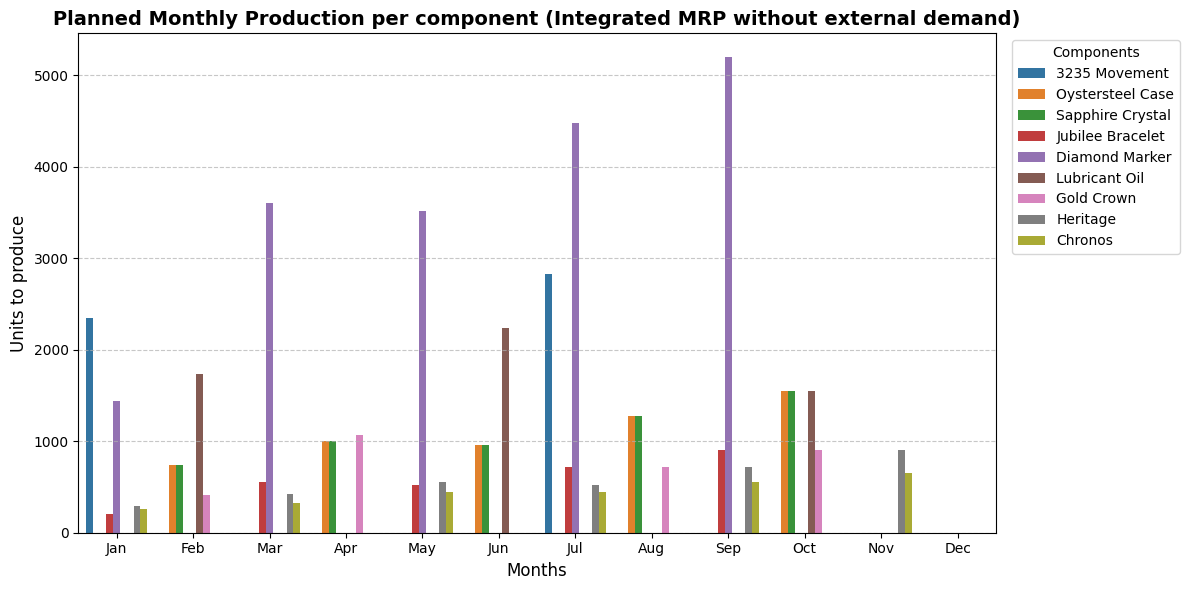

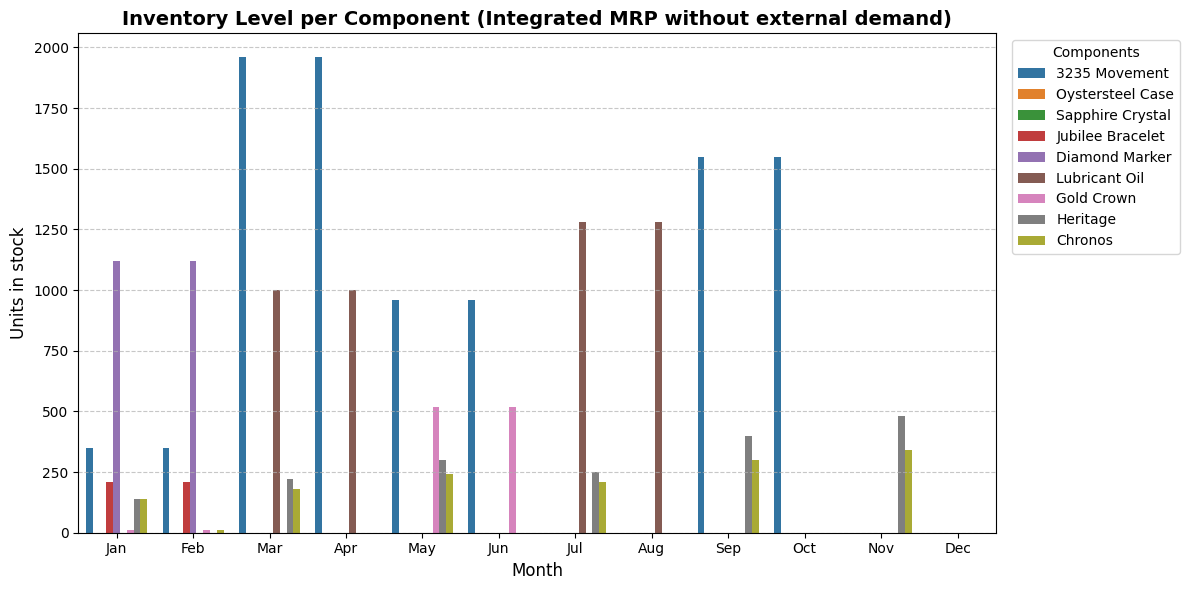

In [ ]:
mrp_int_details = result_mrp_int["Details"]

all_data_int = []
for component_name_int, df_int in mrp_int_details.items():
    temp_df_int = df_int.copy()
    temp_df_int["Component"] = component_name_int
    all_data_int.append(temp_df_int)
combined_df_int = pd.concat(all_data_int)

# Graph 1 : Monthly production
plt.figure(figsize=(12, 6))

sns.barplot(
    data=combined_df_int,
    x="Month",
    y="Production_start",
    hue="Component",
    palette="tab10"
)

plt.title("Planned Monthly Production per component (Integrated MRP without external demand)", fontsize=14, fontweight="bold")
plt.xlabel("Months", fontsize=12)
plt.ylabel("Units to produce", fontsize=12)
plt.xticks(ticks=months_index, labels=months)
plt.legend(title="Components", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

# Monthly inventory
plt.figure(figsize=(12, 6))

sns.barplot(
    data=combined_df_int,
    x="Month",
    y="Final_inv",
    hue="Component",
    palette="tab10"
)

plt.title("Inventory Level per Component (Integrated MRP without external demand)", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Units in stock", fontsize=12)
plt.xticks(ticks=months_index, labels=months)
plt.legend(title="Components", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

### 3.3. Comparison of the sequential MRP and integrated MRP

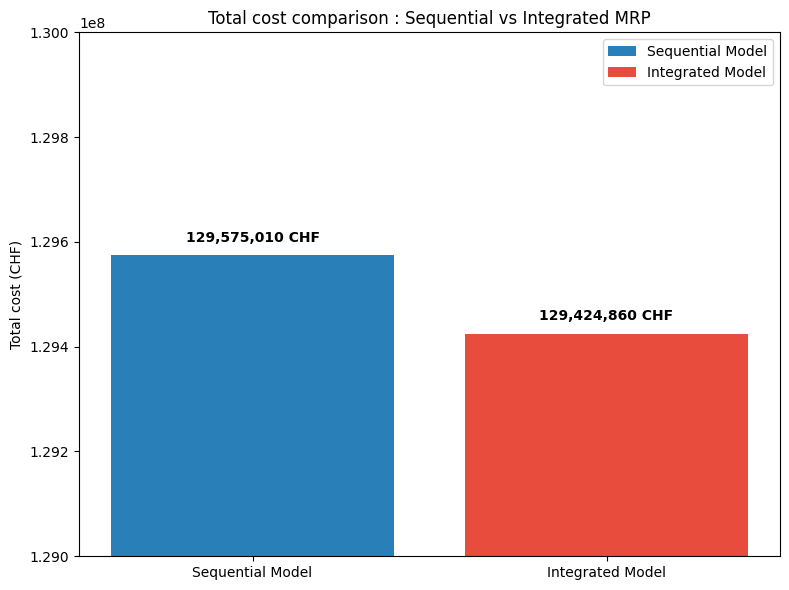

In [ ]:
cost_seq = result_mrp_seq["Total_Cost"]
total_cost_seq = cost_lsc + cost_seq
cost_int = result_mrp_int["Total_Cost"]

plt.figure(figsize=(8, 6))
plt.bar("Sequential Model", total_cost_seq, color="#2980b9", label="Sequential Model")
plt.bar("Integrated Model", cost_int, color="#e74c3c", label="Integrated Model")
plt.title("Total cost comparison : Sequential vs Integrated MRP")
plt.ylabel("Total cost (CHF)")
plt.ylim(bottom=129000000, top=130000000)
plt.text(0, total_cost_seq + 20000, f"{total_cost_seq:,.0f} CHF", ha="center", va="bottom", fontweight="bold")
plt.text(1, cost_int + 20000, f"{cost_int:,.0f} CHF", ha="center", va="bottom", fontweight="bold")
plt.legend()

plt.tight_layout()
plt.show()

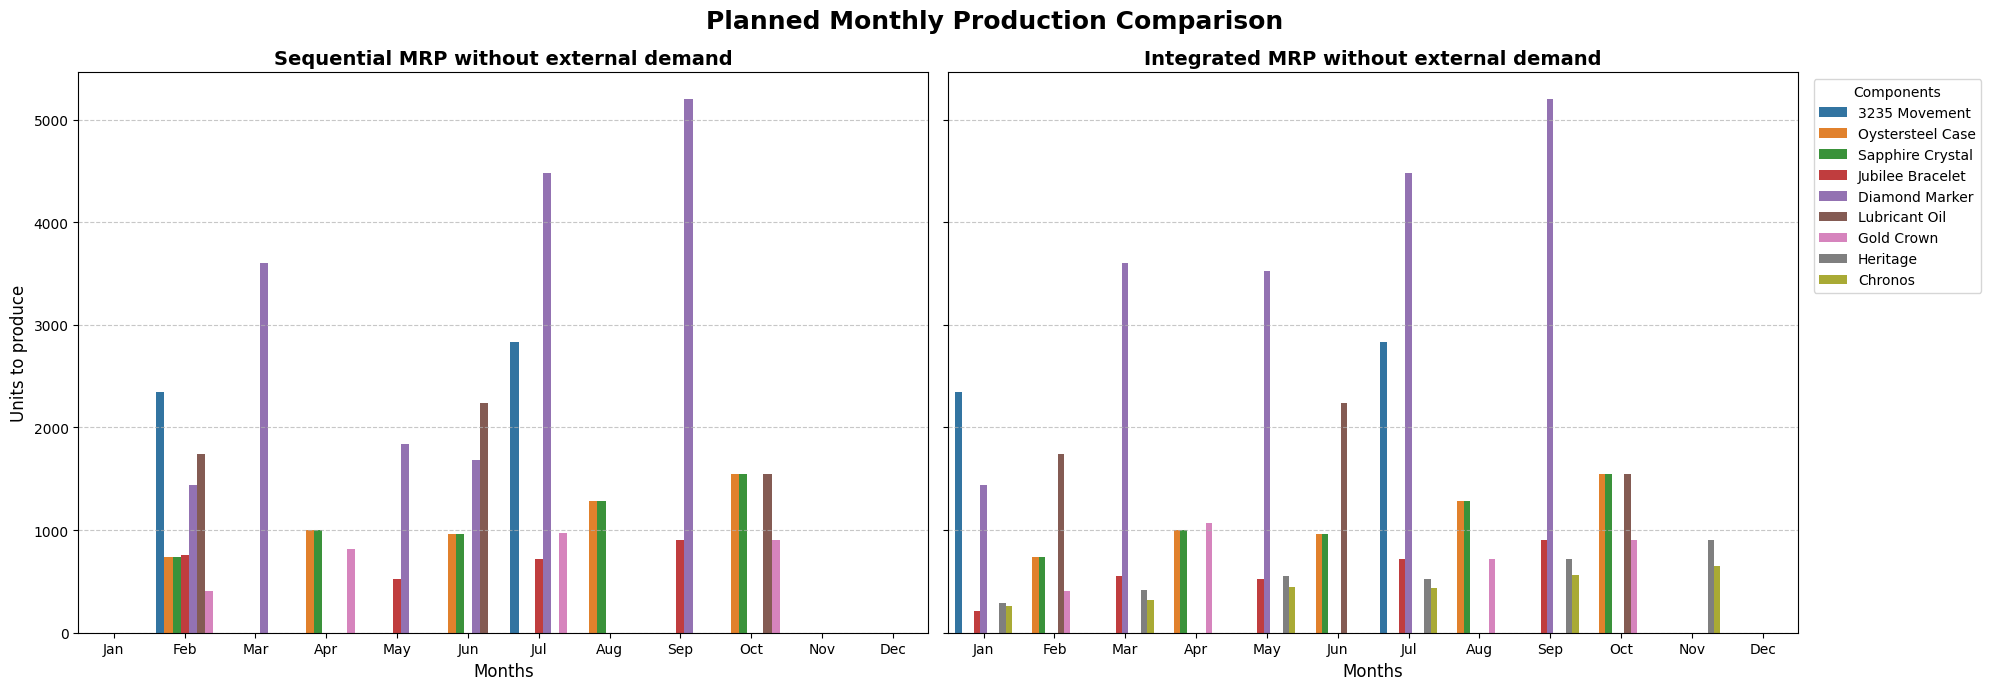

In [ ]:
mrp_seq_details = result_mrp_seq["Details"]
mrp_int_details = result_mrp_int["Details"]

all_data_seq = []
for component_name_seq, df_seq in mrp_seq_details.items():
    temp_df_seq = df_seq.copy()
    temp_df_seq["Component"] = component_name_seq
    all_data_seq.append(temp_df_seq)
combined_df_seq = pd.concat(all_data_seq)

all_data_int = []
for component_name_int, df_int in mrp_int_details.items():
    temp_df_int = df_int.copy()
    temp_df_int["Component"] = component_name_int
    all_data_int.append(temp_df_int)
combined_df_int = pd.concat(all_data_int)

# Monthly Production without external demand
## Sequential
fig, axes = plt.subplots(1, 2, figsize=(20,7), sharey=True)
fig.suptitle("Planned Monthly Production Comparison", fontsize=18, fontweight="bold", y=0.98)

sns.barplot(
    data=combined_df_seq,
    x="Month",
    y="Production_start",
    hue="Component",
    palette="tab10",
    ax=axes[0]
)

axes[0].set_title("Sequential MRP without external demand", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Months", fontsize=12)
axes[0].set_ylabel("Units to produce", fontsize=12)
axes[0].set_xticks(ticks=months_index, labels=months)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].get_legend().remove()


# Integrated
sns.barplot(
    data=combined_df_int,
    x="Month",
    y="Production_start",
    hue="Component",
    palette="tab10",
    ax=axes[1]
)

axes[1].set_title("Integrated MRP without external demand", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Months", fontsize=12)
axes[1].set_ylabel("Units to produce", fontsize=12)
axes[1].set_xticks(ticks=months_index, labels=months)
axes[1].legend(title="Components", bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


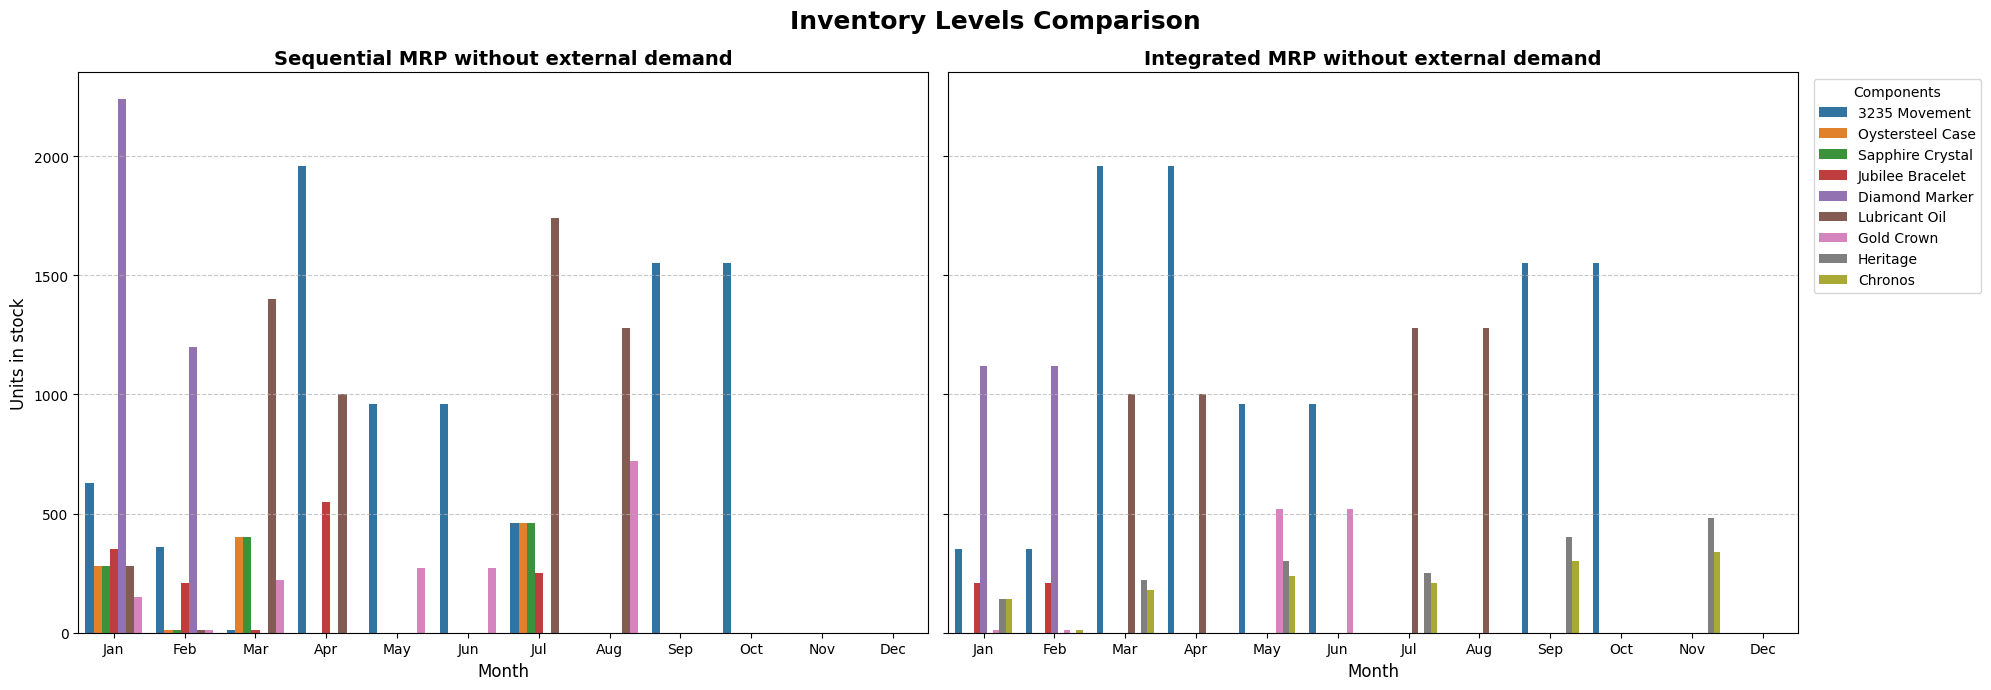

In [ ]:
# Monthly inventory without external demand
## Sequential
fig, axes = plt.subplots(1, 2, figsize=(20,7), sharey=True)
fig.suptitle("Inventory Levels Comparison", fontsize=18, fontweight="bold", y=0.98)

sns.barplot(
    data=combined_df_seq,
    x="Month",
    y="Final_inv",
    hue="Component",
    palette="tab10",
    ax=axes[0]
)

axes[0].set_title("Sequential MRP without external demand", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Month", fontsize=12)
axes[0].set_ylabel("Units in stock", fontsize=12)
axes[0].set_xticks(ticks=months_index, labels=months)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].get_legend().remove()

## Integrated
sns.barplot(
    data=combined_df_int,
    x="Month",
    y="Final_inv",
    hue="Component",
    palette="tab10"
)

axes[1].set_title("Integrated MRP without external demand", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Month", fontsize=12)
axes[1].set_ylabel("Units in stock", fontsize=12)
axes[1].set_xticks(ticks=months_index, labels=months)
axes[1].legend(title="Components", bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Transitioning from sequential planning to an integrated optimization model has significantly improved factory performance, delivering three major benefits:
* Cost Reduction: Total annual costs dropped from 129,575,010 to 129,424,860. By simultaneously optimizing finished watches and their components, the integrated model uncovers global synergies that the level-by-level approach inherently misses.
* Production Smoothing & Feasibility: The integrated model anticipates the demand better and smooths the workload across the year.
* Dynamic Batching Strategy: Forecasting allows us to strategically consolidate production runs, safely reducing both machine setup frequency and inventory holding levels.
### 3.4. Impact of external demand on component allocation
The two models above plan the components production by considering only internal demand. However, Aurelius SA provides Oystersteel cases for external customers as well. THus, the company needs to adapt its production plan to make sure that the demand for both, B2B and B2C customers, is satisfied.

In [ ]:
# External demand for Oystersteel Cases over the 12-month horizon
# (Months 1 to 6 given, assuming 0 for the rest of the year)
external_demand_oystersteel = [10, 15, 18, 22, 25, 28, 0, 0, 0, 0, 0, 0]
print("Total external demand for Oystersteel cases:", sum(external_demand_oystersteel))

Total external demand for Oystersteel cases: 118


#### 3.4.1. Sequential MRP

In [ ]:
# Oystersteel case production with external demand
result_mrp_seq_ext = mrp_sequential(
    mps_heritage, mps_chronos, external_demand_oystersteel,
    components, bom, lead_times, initial_inventory,
    production_costs, holding_costs, setup_costs, ext_d=True
)

print(f"Status : {result_mrp_seq_ext["Status"]}")
print(f"Total cost of components supply : {result_mrp_seq_ext["Total_Cost"]:,.0f} CHF")

print(f"\n--- Detailed plan for Oystersteel Case with external demand ---")
display(result_mrp_seq_ext["Details"]["Oystersteel Case"])

Status : Optimal
Total cost of components supply : 69,741,570 CHF

--- Detailed plan for Oystersteel Case with external demand ---


,Month,Demand,Production_start,Final_inv,Setup
0,0,280.0,383.0,270.0,1.0
1,1,285.0,0.0,368.0,0.0
2,2,368.0,422.0,0.0,1.0
3,3,422.0,1053.0,0.0,1.0
4,4,1025.0,0.0,28.0,0.0
5,5,28.0,960.0,0.0,1.0
6,6,500.0,0.0,460.0,0.0
7,7,460.0,1280.0,0.0,1.0
8,8,1280.0,0.0,0.0,0.0
9,9,0.0,1550.0,0.0,1.0


In [ ]:
print(f"\n--- Detailed plan for Oystersteel Case without external demand ---")
display(result_mrp_seq["Details"]["Oystersteel Case"])


--- Detailed plan for Oystersteel Case without external demand ---


,Month,Demand,Production_start,Final_inv,Setup
0,0,270.0,0.0,280.0,0.0
1,1,270.0,740.0,10.0,1.0
2,2,350.0,0.0,400.0,0.0
3,3,400.0,1000.0,0.0,1.0
4,4,1000.0,0.0,0.0,0.0
5,5,0.0,960.0,0.0,1.0
6,6,500.0,0.0,460.0,0.0
7,7,460.0,1280.0,0.0,1.0
8,8,1280.0,0.0,0.0,0.0
9,9,0.0,1550.0,0.0,1.0


5 setups in months [1, 3, 5, 7, 9]
6 setups in months [0, 2, 3, 5, 7, 9]


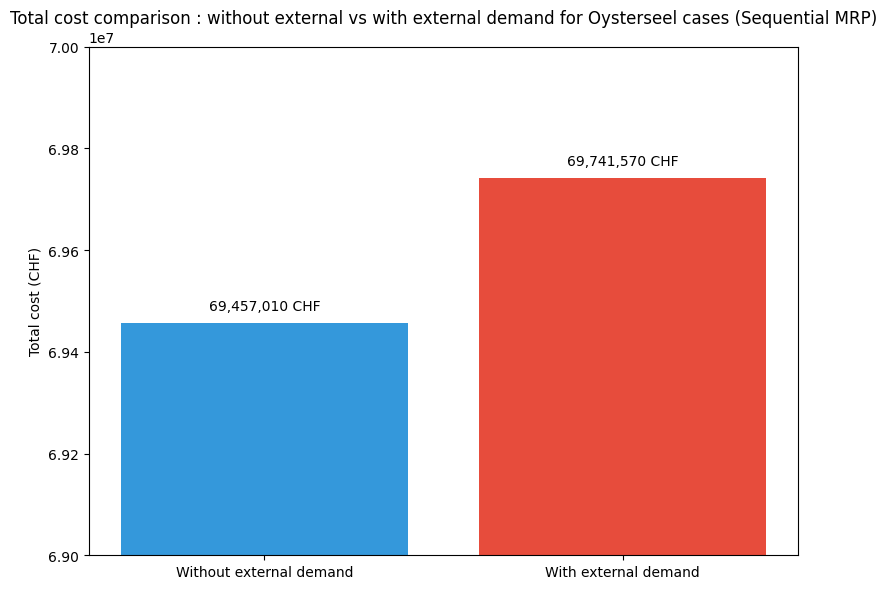

In [ ]:
seq_oyster = result_mrp_seq["Details"]["Oystersteel Case"].copy()
seq_oyster_ext = result_mrp_seq_ext["Details"]["Oystersteel Case"].copy()
month_setup_seq = seq_oyster.index[seq_oyster["Setup"] > 0].tolist()
month_setup_seq_ext = seq_oyster_ext.index[seq_oyster_ext["Setup"] > 0].tolist()
n_setups_seq = len(month_setup_seq)
n_setups_seq_ext = len(month_setup_seq_ext)
print(f"{n_setups_seq} setups in months {month_setup_seq}")
print(f"{n_setups_seq_ext} setups in months {month_setup_seq_ext}")

cost_seq_ext = result_mrp_seq_ext["Total_Cost"]

labels_ext = ["Without external demand", "With external demand"]
costs_seq = [cost_seq, cost_seq_ext]

plt.figure(figsize=(8, 6))

bars = plt.bar(labels_ext, costs_seq, color=["#3498db", "#e74c3c"])
plt.title("Total cost comparison : without external vs with external demand for Oysterseel cases (Sequential MRP)")
plt.ylabel("Total cost (CHF)")
plt.ylim(bottom=69000000, top=70000000)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20000, f"{yval:,.0f} CHF", ha="center", va="bottom")

plt.tight_layout()
plt.show()

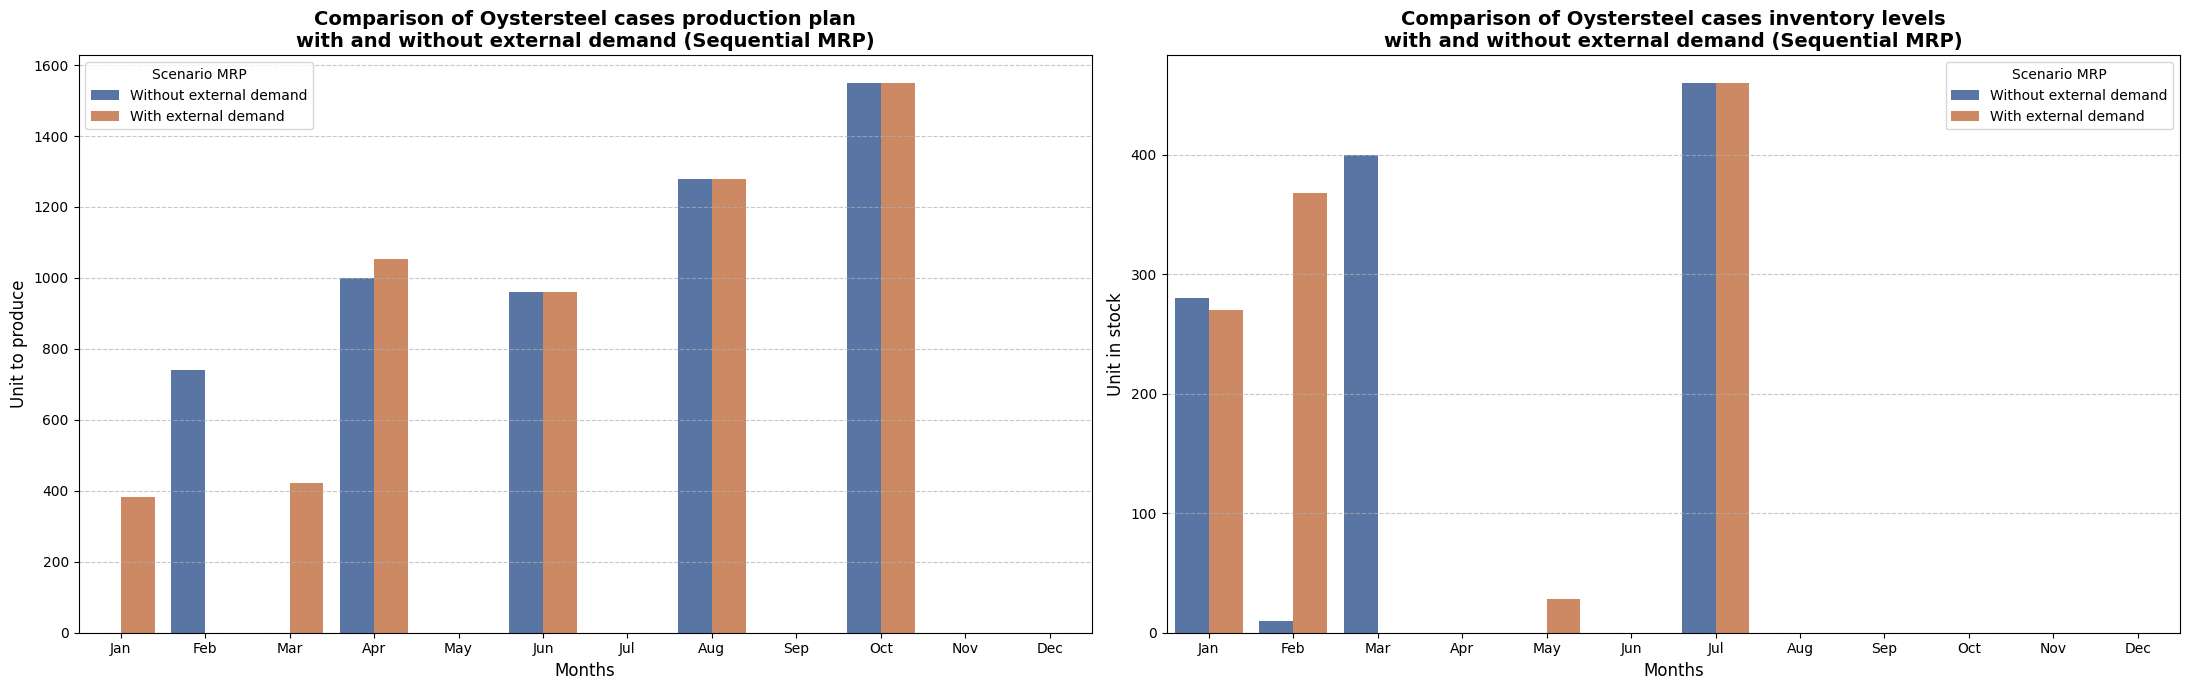

In [ ]:
seq_oyster["Scenario"] = "Without external demand"
seq_oyster_ext["Scenario"] = "With external demand"

df_seq_comparison = pd.concat([seq_oyster, seq_oyster_ext])

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

# --- Graph 1 : Production
sns.barplot(
    data=df_seq_comparison,
    x="Month",
    y="Production_start",
    hue="Scenario",
    palette=["#4C72B0", "#DD8452"],
    ax=axes[0]
)

axes[0].set_title("Comparison of Oystersteel cases production plan\nwith and without external demand (Sequential MRP)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Months", fontsize=12)
axes[0].set_ylabel("Unit to produce", fontsize=12)
axes[0].set_xticks(ticks=months_index, labels=months)
axes[0].legend(title="Scenario MRP")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# --- Graph 2 : Inventory
sns.barplot(
    data=df_seq_comparison,
    x="Month",
    y="Final_inv",
    hue="Scenario",
    palette=["#4C72B0", "#DD8452"],
    ax=axes[1]
)

axes[1].set_title("Comparison of Oystersteel cases inventory levels\nwith and without external demand (Sequential MRP)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Months", fontsize=12)
axes[1].set_ylabel("Unit in stock", fontsize=12)
axes[1].set_xticks(ticks=months_index, labels=months)
axes[1].legend(title="Scenario MRP")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

The impact of the external demand is driven by a low but disruptive volume of only 118 additional units spread across January to June, after which both scenarios become strictly identical. Additionally to the total cost increase from 69,457,010 to 69,741,570, this slight surplus forces the system to trigger six production runs over the year instead of five. This results in a loss of batch optimization; while the system smartly consolidates a large production run of 740 units in February without external demand, the added volume forces it to fragment the batches and launch earlier in January and March. Consequently, the inventory peak is shifted forward to January and February rather than being in January and March.

#### 3.4.2. Integrated MRP

In [ ]:
result_mrp_int_ext = mrp_integrated(demands, external_demand_oystersteel, components, bom, lead_times, initial_inventory,
                   production_costs, holding_costs, setup_costs, s0_list, p_list, h_list, q_list,
                   capacity_limit, unit_hours, setup_hours, peak_months, peak_mult, ext_d=True)

print(f"Status : {result_mrp_int_ext['Status']}")
print(f"Total cost : {result_mrp_int_ext['Total_Cost']:,.0f} CHF")

print(f"\n--- Detailed plan for Oystersteel Case (Integrated) ---")
display(result_mrp_int_ext["Details"]["Oystersteel Case"])

Status : Optimal
Total cost : 129,692,970 CHF

--- Detailed plan for Oystersteel Case (Integrated) ---


,Month,Demand,Production_start,Final_inv,Setup
0,0,550.0,383.0,0.0,1.0
1,1,365.0,0.0,18.0,0.0
2,2,18.0,1475.0,0.0,1.0
3,3,1422.0,0.0,53.0,0.0
4,4,25.0,0.0,28.0,0.0
5,5,28.0,960.0,0.0,1.0
6,6,960.0,0.0,0.0,0.0
7,7,0.0,1280.0,0.0,1.0
8,8,1280.0,0.0,0.0,0.0
9,9,0.0,1550.0,0.0,1.0


5 setups in months [1, 3, 5, 7, 9]
5 setups in months [0, 2, 5, 7, 9]


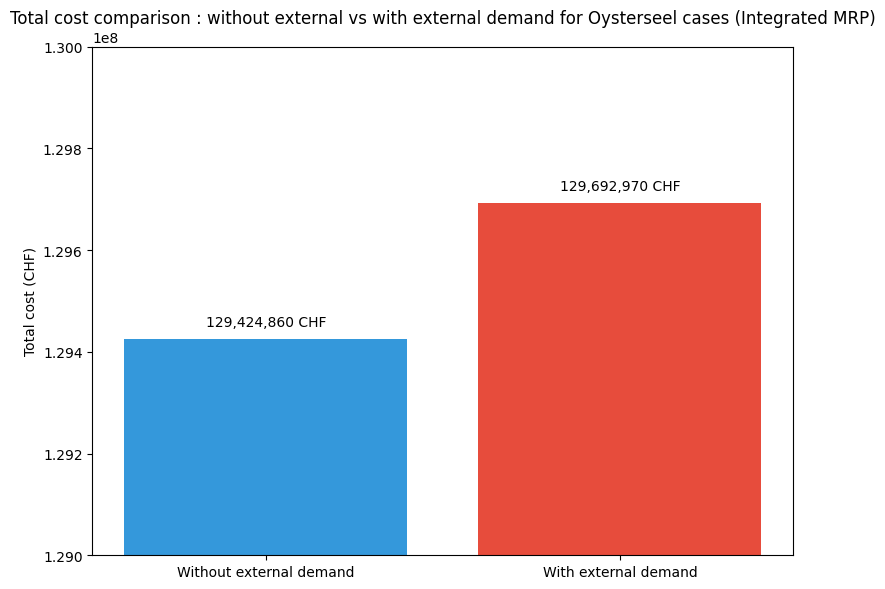

In [ ]:
int_oyster = result_mrp_int["Details"]["Oystersteel Case"].copy()
int_oyster_ext = result_mrp_int_ext["Details"]["Oystersteel Case"].copy()
month_setup_int = int_oyster.index[int_oyster["Setup"] > 0].tolist()
month_setup_int_ext = int_oyster_ext.index[int_oyster_ext["Setup"] > 0].tolist()
n_setups_int = len(month_setup_int)
n_setups_int_ext = len(month_setup_int_ext)
print(f"{n_setups_int} setups in months {month_setup_int}")
print(f"{n_setups_int_ext} setups in months {month_setup_int_ext}")

cost_int_ext = result_mrp_int_ext["Total_Cost"]

costs_int = [cost_int, cost_int_ext]

plt.figure(figsize=(8, 6))

bars = plt.bar(labels_ext, costs_int, color=["#3498db", "#e74c3c"])
plt.title("Total cost comparison : without external vs with external demand for Oysterseel cases (Integrated MRP)")
plt.ylabel("Total cost (CHF)")
plt.ylim(bottom=129000000, top=130000000)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20000, f"{yval:,.0f} CHF", ha="center", va="bottom")

plt.tight_layout()
plt.show()

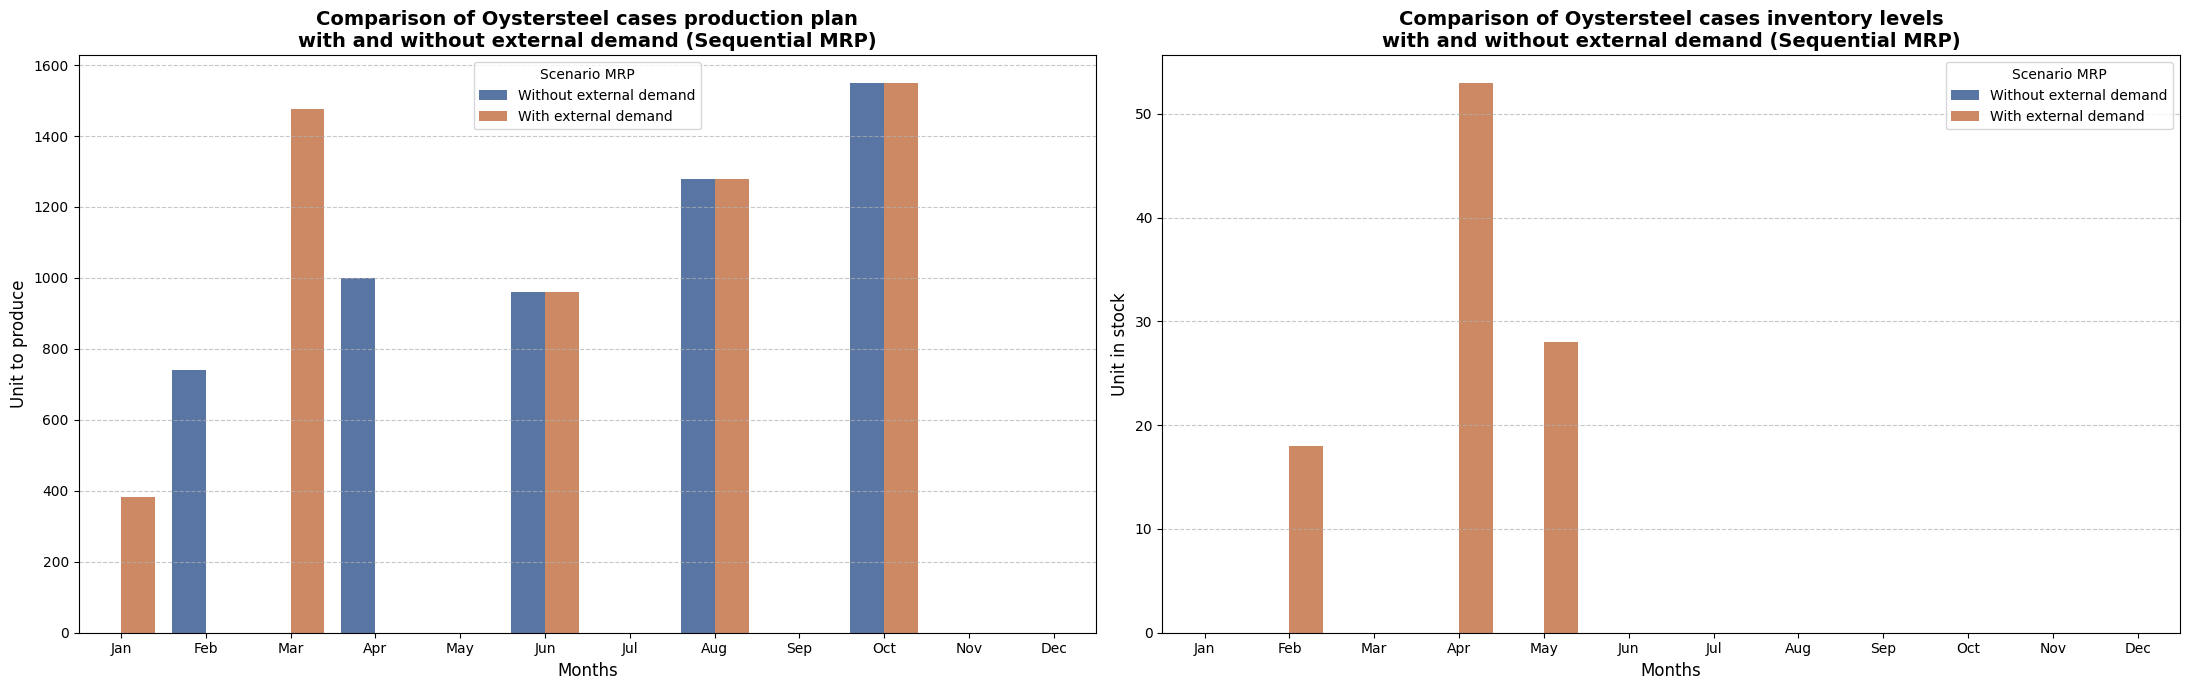

In [ ]:
int_oyster["Scenario"] = "Without external demand"
int_oyster_ext["Scenario"] = "With external demand"

df_int_comparison = pd.concat([int_oyster, int_oyster_ext])

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

# --- Graph 1 : Production
sns.barplot(
    data=df_int_comparison,
    x="Month",
    y="Production_start",
    hue="Scenario",
    palette=["#4C72B0", "#DD8452"],
    ax=axes[0]
)

axes[0].set_title("Comparison of Oystersteel cases production plan\nwith and without external demand (Sequential MRP)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Months", fontsize=12)
axes[0].set_ylabel("Unit to produce", fontsize=12)
axes[0].set_xticks(ticks=months_index, labels=months)
axes[0].legend(title="Scenario MRP")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# --- Graph 2 : Inventory
sns.barplot(
    data=df_int_comparison,
    x="Month",
    y="Final_inv",
    hue="Scenario",
    palette=["#4C72B0", "#DD8452"],
    ax=axes[1]
)

axes[1].set_title("Comparison of Oystersteel cases inventory levels\nwith and without external demand (Sequential MRP)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Months", fontsize=12)
axes[1].set_ylabel("Unit in stock", fontsize=12)
axes[1].set_xticks(ticks=months_index, labels=months)
axes[1].legend(title="Scenario MRP")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In the integrated MRP, the introduction of external demand increases the cost from 129,424,860 to 129,692,970 and forces production to start immediately in January to cover a 900-unit requirement, whereas the internal-only scenario relies on initial inventory and delays production until February. To handle the subsequent fragmented external demand, the integrated MRP smartly overproduces slightly in January and March. This creates small, temporary inventory buffers that absorb the extra volume without triggering costly new setups. As a result, both scenarios maintain exactly five setups across the year, operating identically from June onwards.

#### 3.4.3 Analysis of the internal-external demand trade-off
Based on the Material Requirements Planning (MRP) optimization models, we analyzed the impact of introducing external demand for Oystersteel cases on our overall production plan and cost structure. The comparison between the baseline scenario (internal demand only) and the extended scenario (internal + external demand) yields the following strategic insights:

1. Risk of Component Shortage for Internal Production

*If too many Oystersteel cases go to external sales, will there be enough for internal watch production?*

In an uncapacitated model, the system simply schedules larger production batches to satisfy both demands. However, from a practical managerial perspective, allocating too many Oystersteel cases to external partners introduces a significant supply chain risk. If the workshop faces capacity constraints (such as limited machine hours or labor availability), fulfilling high external demand will saturate our production line. This would inevitably lead to stockouts of Oystersteel cases for internal use, thereby blocking the final assembly of our Heritage and Chronos watches.

2. Strategic Prioritization

*Should Aurelius prioritize internal assembly or external sales?*

Aurelius must strictly prioritize internal assembly. The core business value and profit margins derived from selling finished luxury watches (Heritage and Chronos) being probably higher than those from selling individual raw components. Internal demand for Oystersteel cases must be treated as a non-negotiable constraint within the production plan. It is crucial to emphasize that a shortage of Oystersteel cases will block the entire watch production process, even if all other required components have been produced and are in stock. External sales should therefore be viewed strictly as a secondary revenue stream that is only pursued when excess capacity allows, ensuring that they never cannibalize the production of finished goods.

3. Optimal Allocation and Profitability

*What is the most profitable way to allocate components between internal and external clients?*

The most profitable allocation strategy requires a marginal profitability analysis. As demonstrated by the two MRP outputs, integrating external demand significantly disrupts the baseline production plan. It forces the system to either increase batch sizes (driving up inventory holding costs) or trigger additional production runs (increasing setup costs), which is reflected in the higher total cost of the MRP.

Therefore, Aurelius should only allocate Oystersteel cases to external clients if the revenue generated from these external sales exceeds the marginal cost increase observed in the MRP plan (i.e., the difference in total cost between the scenario with external demand and the scenario without). The optimal approach is to secure 100% of internal requirements first, and then evaluate the external demand order-by-order, accepting it only if the net profit is strictly positive.

# **III. Sensitivity Analysis : Robustness of the production plan**


While the  integrated MRP model provide a mathematically optimal production schedule for Aurelius SA, it relies on static, deterministic assumptions. In the dynamic landscape of high-end watchmaking, parameters such as component availability, operational costs, and workshop capacities are frequently subject to real-world volatility.

To ensure our strategic decisions remain resilient under uncertainty, this section conducts a comprehensive sensitivity analysis. By systematically adjusting key variables, we aim to "stress-test" the production plan and extract actionable insights for the management team. Rather than viewing the initial schedule as a rigid directive, this analysis provides a dynamic framework to understand how the system reacts to change.

Specifically, we evaluate the impact of shifting parameters across three critical operational dimensions:
* Cost Volatility: How fluctuations in setup, holding and peak-time costs affect optimal batch sizes and working capital.
* Capacity Constraints: How tightening or relaxing the 18,000-hour monthly limit forces early production and inventory pre-building.
* Supply Chain Disruptions: How extended component lead times impact MRP ordering schedules and supplier dependencies.

By exploring these scenarios, we equip the management team with actionable insights to proactively adapt production strategies and mitigate operational risks.

### 1. Cost volatility impact

#### 1.1 Setup costs variation

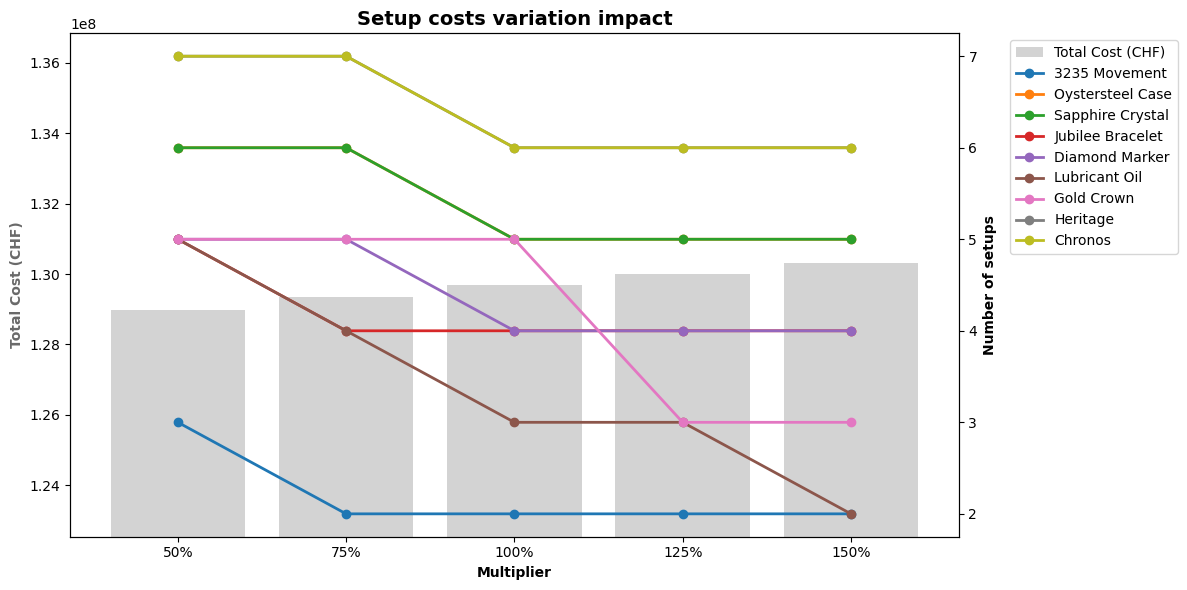

In [ ]:
multipliers = [0.5, 0.75, 1.0, 1.25, 1.5]

# Setup
setup_sens_results = []
item_setups_data = {}

for mult in multipliers:
    adj_setup = {k: v * mult for k, v in setup_costs.items()}
    adj_q_list = [q * mult for q in q_list]

    res_setup = mrp_integrated(
        demands, external_demand_oystersteel, components, bom, lead_times, initial_inventory,
        production_costs, holding_costs, adj_setup,
        s0_list, p_list, h_list, adj_q_list,
        capacity_limit, unit_hours, setup_hours, peak_months, peak_mult, ext_d=True
    )

    setup_sens_results.append({
        "Multiplier": f"{int(mult * 100)}%",
        "Total_Cost_CHF": res_setup["Total_Cost"]
    })

    for item, df in res_setup["Details"].items():
        if item not in item_setups_data:
            item_setups_data[item] = []
        item_setups_data[item].append(df["Setup"].sum())

df_setup_sens = pd.DataFrame(setup_sens_results)

# Graph
fig1, ax1 = plt.subplots(figsize=(12, 6))
x_labels = df_setup_sens["Multiplier"]
x = range(len(x_labels))

color_cost = "lightgray"
ax1.bar(x, df_setup_sens["Total_Cost_CHF"], color=color_cost, label="Total Cost (CHF)")
ax1.set_xlabel("Multiplier", fontweight="bold")
ax1.set_ylabel("Total Cost (CHF)", color="dimgray", fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels)
ax1.set_ylim(bottom=df_setup_sens["Total_Cost_CHF"].min() * 0.95)

ax2 = ax1.twinx()
ax2.set_ylabel("Number of setups", fontweight="bold")

for item, setups_list in item_setups_data.items():
    ax2.plot(x, setups_list, marker="o", linewidth=2, label=item)

plt.title("Setup costs variation impact", fontsize=14, fontweight="bold")
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", bbox_to_anchor=(1.05, 1))

fig1.tight_layout()
plt.show()

As the financial penalty for initiating a production run increases the production plan consists of fewer, larger batches.

However, not all items react with the same sensitivity:
* Highly Sensitive: Items like Lubricant Oil (dropping from 5 setups down to 2) and Gold Crown (dropping from 5 to 3) show high flexibility. The model prefers to stockpile these items rather than pay higher machine changeover costs.
* Rigid Constraints: Components like the Jubilee Bracelet quickly hit a floor (dropping from 5 to 4 setups and staying flat). This indicates that their production is tightly bound by other constraints, such as raw capacity limits or exact timing dependencies, preventing further consolidation.


The Total Cost inevitably rises as the multiplier increases, the scale of the increase is highly controlled. By dynamically reducing the number of setups, the model prevents the Total Cost from scaling linearly with the setup cost multiplier.

**Strategic Takeaways & Actionable Advice**

If the engineering team can physically reduce setup times and costs (moving toward the 50% scenario), the factory can afford to run far more frequent setups (e.g., 7 setups for Chronos). This unlocks a highly agile, "Just-in-Time" production model that reacts better to demand shocks and lowers warehouse clutter.

Conversely, if setup costs rise in reality (e.g., higher labor rates for changeovers), the company must accept the model's strategy of larger batches. Management should ensure there is adequate physical warehouse space and working capital to handle the resulting spikes in holding inventory.


#### 1.2. Holding costs variation

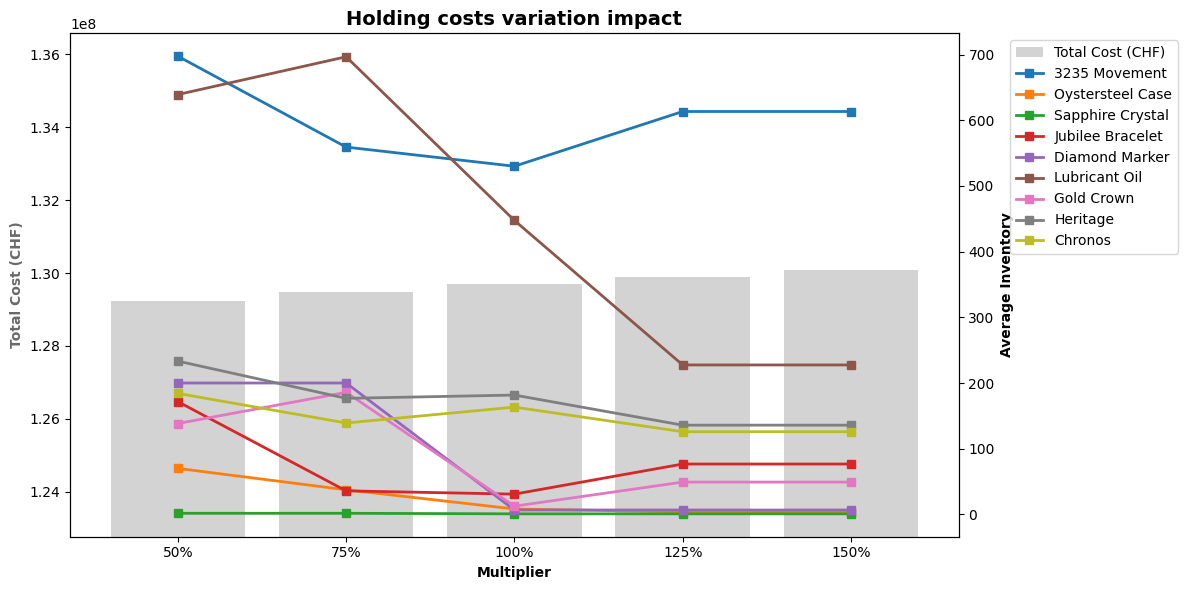

In [ ]:
# Holding costs
holding_sens_results = []
item_inventory_data = {}

for mult in multipliers:
    adj_holding = {k: v * mult for k, v in holding_costs.items()}
    adj_h_list = [h * mult for h in h_list]

    res_holding = mrp_integrated(
        demands, external_demand_oystersteel, components, bom, lead_times, initial_inventory,
        production_costs, adj_holding, setup_costs,
        s0_list, p_list, adj_h_list, q_list,
        capacity_limit, unit_hours, setup_hours, peak_months, peak_mult, ext_d=True
    )

    holding_sens_results.append({
        "Multiplier": f"{int(mult * 100)}%",
        "Total_Cost_CHF": res_holding["Total_Cost"]
    })

    for item, df in res_holding["Details"].items():
        if item not in item_inventory_data:
            item_inventory_data[item] = []
        item_inventory_data[item].append(df["Final_inv"].mean())

df_holding_sens = pd.DataFrame(holding_sens_results)

# Graph
fig2, ax3 = plt.subplots(figsize=(12, 6))
x_labels_h = df_holding_sens["Multiplier"]
x_h = range(len(x_labels_h))

ax3.bar(x_h, df_holding_sens["Total_Cost_CHF"], color=color_cost, label="Total Cost (CHF)")
ax3.set_xlabel("Multiplier", fontweight="bold")
ax3.set_ylabel("Total Cost (CHF)", color="dimgray", fontweight="bold")
ax3.set_xticks(x_h)
ax3.set_xticklabels(x_labels_h)
ax3.set_ylim(bottom=df_holding_sens["Total_Cost_CHF"].min() * 0.95)

ax4 = ax3.twinx()
ax4.set_ylabel("Average Inventory", fontweight="bold")

for item, inv_list in item_inventory_data.items():
    ax4.plot(x_h, inv_list, marker="s", linewidth=2, label=item)

plt.title("Holding costs variation impact", fontsize=14, fontweight="bold")

lines_3, labels_3 = ax3.get_legend_handles_labels()
lines_4, labels_4 = ax4.get_legend_handles_labels()
ax4.legend(lines_3 + lines_4, labels_3 + labels_4, loc="upper left", bbox_to_anchor=(1.05, 1))

fig2.tight_layout()
plt.show()

As holding costs increase, the optimization model actively defends profitability by shifting flexible components (like Lubricant Oil) toward a Just-In-Time strategy, aggressively reducing their warehouse footprint to save cash. However, the critical anomaly is the 3235 Movement, whose average inventory actually increases at the highest cost multipliers. This counter-intuitive behavior reveals a severe production bottleneck: the system is mathematically forced to stockpile these specific parts well in advance—despite the punishing storage fees—because it lacks the capacity to build them on demand during peak months. Management should therefore urgently investigate targeted capacity upgrades for the 3235 Movement, rather than applying a blanket inventory reduction policy across the entire factory.


#### 1.3. Peak-time costs variation

--- Sensitivity: Peak Time Costs ---


,Peak_Multiplier,Total_Cost_CHF
0,x1.0,129663230.0
1,x1.5,129692970.0
2,x2.0,129692970.0
3,x2.5,129692970.0
4,x3.0,129692970.0


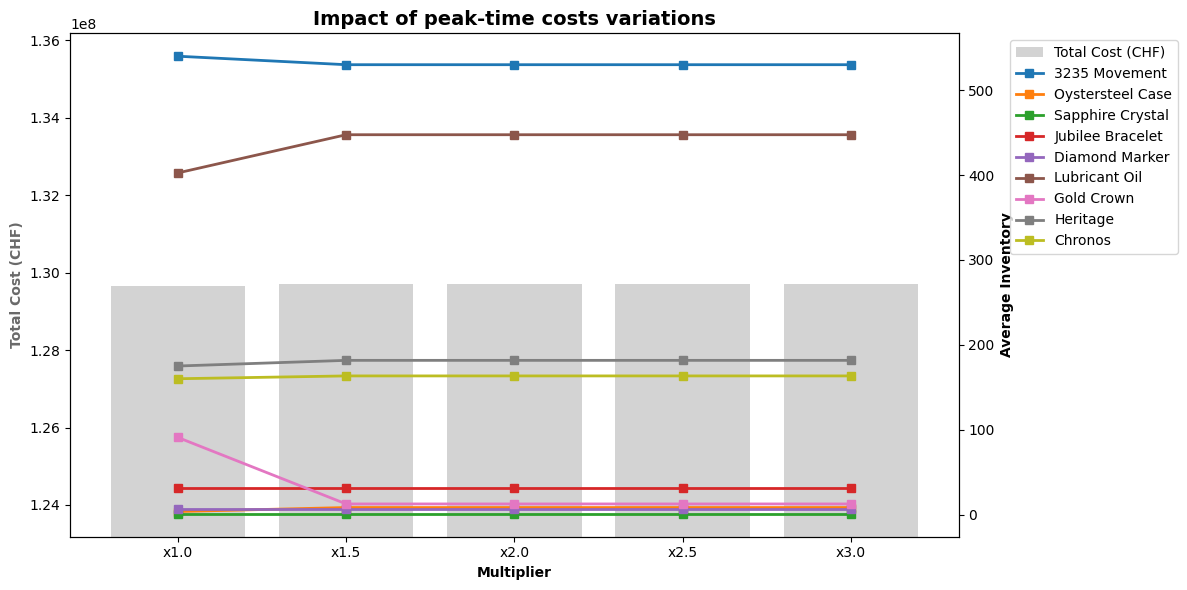

In [ ]:
peak_multipliers = [1.0, 1.5, 2.0, 2.5, 3.0]

peak_sens_results = []
item_inventory_data_peak = {}

for mult in peak_multipliers:
    res_peak = mrp_integrated(
        demands, external_demand_oystersteel, components, bom, lead_times, initial_inventory,
        production_costs, holding_costs, setup_costs,
        s0_list, p_list, h_list, q_list,
        capacity_limit, unit_hours, setup_hours, peak_months, mult, ext_d=True
    )

    peak_sens_results.append({
        "Peak_Multiplier": f"x{mult}",
        "Total_Cost_CHF": res_peak["Total_Cost"],
    })

    for item, df in res_peak["Details"].items():
        if item not in item_inventory_data_peak:
            item_inventory_data_peak[item] = []
        item_inventory_data_peak[item].append(df["Final_inv"].mean())

df_peak_sens = pd.DataFrame(peak_sens_results)
print("--- Sensitivity: Peak Time Costs ---")
display(df_peak_sens)

# Graph
fig3, ax5 = plt.subplots(figsize=(12, 6))
x_labels_p = df_peak_sens["Peak_Multiplier"]
x_p = range(len(x_labels_p))

color_cost = "lightgray"
ax5.bar(x_p, df_peak_sens["Total_Cost_CHF"], color=color_cost, label="Total Cost (CHF)")
ax5.set_xlabel("Multiplier", fontweight="bold")
ax5.set_ylabel("Total Cost (CHF)", color="dimgray", fontweight="bold")
ax5.set_xticks(x_p)
ax5.set_xticklabels(x_labels_p)
ax5.set_ylim(bottom=df_peak_sens["Total_Cost_CHF"].min() * 0.95)

ax6 = ax5.twinx()
ax6.set_ylabel("Average Inventory", fontweight="bold")

for item, inv_list in item_inventory_data_peak.items():
    ax6.plot(x_p, inv_list, marker="s", linewidth=2, label=item)

plt.title("Impact of peak-time costs variations", fontsize=14, fontweight="bold")

lines_5, labels_5 = ax5.get_legend_handles_labels()
lines_6, labels_6 = ax6.get_legend_handles_labels()
ax6.legend(lines_5 + lines_6, labels_5 + labels_6, loc="upper left", bbox_to_anchor=(1.05, 1))

fig3.tight_layout()
plt.show()

As peak-time costs increase from 1.0x to 1.5x, the model makes initial operational shifts, such as increasing anticipation stock for Lubricant Oil and leaning out Gold Crowns, to avoid producing during expensive months. However, beyond the 1.5x multiplier, the entire system flatlines, with both average inventory and total costs remaining perfectly static. This indicates that the factory quickly hits a hard capacity limit: it is physically impossible to shift any more production out of the peak months, forcing the system to simply absorb the penalties. Therefore, management should realize that steeper peak-time penalties will not drive further efficiency; instead, they must invest in expanding baseline capacity to allow for more production shifting throughout the year.

### 2. Lead-time volatility impact

--- Sensitivity: Lead Times ---


,Multiplier,Total_Cost_CHF
0,x0.5,109954461
1,x1.0,129663230
2,x1.5,128288337
3,x2.0,128241417


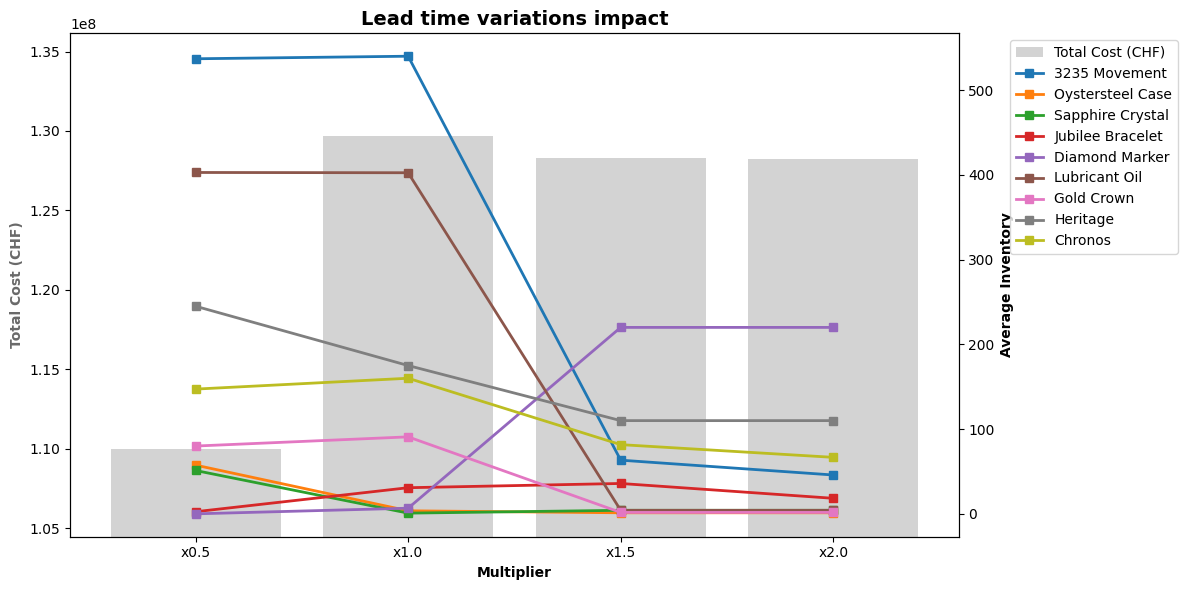

In [ ]:
lt_multipliers = [0.5, 1.0, 1.5, 2.0]

lt_sens_results = []
item_inventory_data_lt = {}

for mult in lt_multipliers:
    # Integers so to avoid half months for exemple
    adj_lead_times = {k: max(0, int(round(v * mult))) for k, v in lead_times.items()}

    res_lt = mrp_integrated(
        demands, external_demand_oystersteel, components, bom, adj_lead_times, initial_inventory,
        production_costs, holding_costs, setup_costs,
        s0_list, p_list, h_list, q_list,
        capacity_limit, unit_hours, setup_hours, peak_months, mult, ext_d=True
        )

    lt_sens_results.append({
        "Multiplier": f"x{mult}",
        "Total_Cost_CHF": round(res_lt["Total_Cost"])
    })

    for item, df in res_lt["Details"].items():
        if item not in item_inventory_data_lt:
            item_inventory_data_lt[item] = []
        item_inventory_data_lt[item].append(df["Final_inv"].mean())

df_lt_sens = pd.DataFrame(lt_sens_results)
print("--- Sensitivity: Lead Times ---")
display(df_lt_sens)

# Graph
fig4, ax7 = plt.subplots(figsize=(12, 6))
x_labels_lt = df_lt_sens["Multiplier"]
x_lt = range(len(x_labels_lt))

color_cost = "lightgray"
ax7.bar(x_lt, df_lt_sens["Total_Cost_CHF"], color=color_cost, label="Total Cost (CHF)")
ax7.set_xlabel("Multiplier", fontweight="bold")
ax7.set_ylabel("Total Cost (CHF)", color="dimgray", fontweight="bold")
ax7.set_xticks(x_lt)
ax7.set_xticklabels(x_labels_lt)
ax7.set_ylim(bottom=df_lt_sens["Total_Cost_CHF"].min() * 0.95)

ax8 = ax7.twinx()
ax8.set_ylabel("Average Inventory", fontweight="bold")

for item, inv_list in item_inventory_data_lt.items():
    ax8.plot(x_lt, inv_list, marker="s", linewidth=2, label=item)

plt.title("Lead time variations impact", fontsize=14, fontweight="bold")

lines_7, labels_7 = ax7.get_legend_handles_labels()
lines_8, labels_8 = ax8.get_legend_handles_labels()
ax8.legend(lines_7 + lines_8, labels_7 + labels_8, loc="upper left", bbox_to_anchor=(1.05, 1))

fig4.tight_layout()
plt.show()

Shortening supplier lead times (x0.5) unlocks the most efficient operational state, significantly reducing total costs while maintaining stable component buffers. Conversely, as lead times artificially extend beyond the baseline (x1.5 and x2.0), the optimization model is forced into a radical restructuring, drastically dumping inventory of major parts like the 3235 Movement while unexpectedly stockpiling Diamond Markers. This erratic shift occurs because extended delays force the system to cannibalize its own schedule, hoarding cheaper, faster-to-produce components just to free up scarce machine hours for the delayed critical parts. Consequently, the factory loses its ability to proactively buffer high-value items, leaving the entire production line dangerously vulnerable to even minor external shocks. Management must therefore prioritize supply chain reliability through dual-sourcing or aggressive negotiation, ensuring that external supplier delays do not dictate internal factory efficiency.

### 3. Capacity variations impact

--- Sensitivity: Production Capacity ---


,Capacity,Hours,Status,Total_Cost_CHF
0,25%,4500,Infeasible,NaN
1,50%,9000,Optimal,130230058.0
2,75%,13500,Optimal,129784393.0
3,100%,18000,Optimal,129692970.0
4,125%,22500,Optimal,129692970.0
5,150%,27000,Optimal,129692970.0
6,175%,31500,Optimal,129692970.0


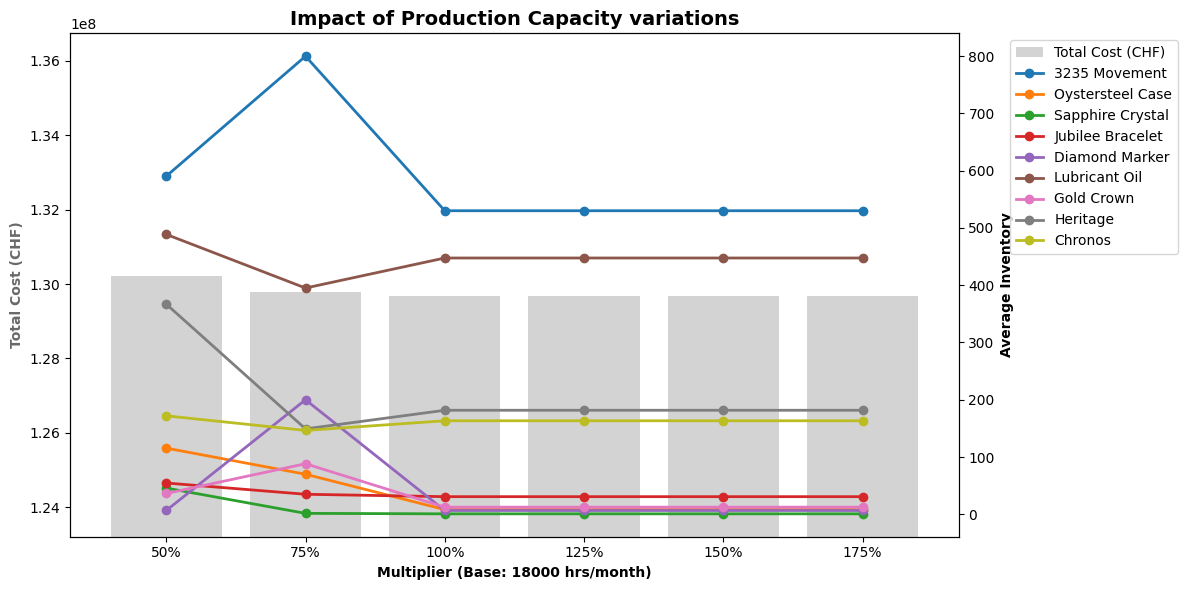

In [ ]:
capacity_multipliers = [0.25, 0.5, 0.75, 1.00, 1.25, 1.5, 1.75]

cap_sens_results = []
item_inventory_data_cap = {}

for mult in capacity_multipliers:
    adj_capacity = int(capacity_limit * mult)

    # Execute the MRP with the dynamically adjusted capacity limit
    res_cap = mrp_integrated(
        demands, external_demand_oystersteel, components, bom, lead_times, initial_inventory,
        production_costs, holding_costs, setup_costs,
        s0_list, p_list, h_list, q_list,
        adj_capacity, unit_hours, setup_hours, peak_months, peak_mult, ext_d=True,
        )

    status = res_cap["Status"]

    cap_sens_results.append({
        "Capacity": f"{int(mult * 100)}%",
        "Hours": adj_capacity,
        "Status": status,
        "Total_Cost_CHF": round(res_cap["Total_Cost"]) if status == "Optimal" else np.nan
    })

    if status == "Optimal":
        for item, df in res_cap["Details"].items():
            if item not in item_inventory_data_cap:
                item_inventory_data_cap[item] = [np.nan] * (len(cap_sens_results) - 1)
            item_inventory_data_cap[item].append(df["Final_inv"].mean())
    else:
        for item in item_inventory_data_cap.keys():
            item_inventory_data_cap[item].append(np.nan)

df_cap_sens = pd.DataFrame(cap_sens_results)
print("--- Sensitivity: Production Capacity ---")
display(df_cap_sens)

# Graph
fig5, ax9 = plt.subplots(figsize=(12, 6))
x_labels_c = df_cap_sens["Capacity"]
x_c = range(len(x_labels_c))

color_cost = "lightgray"
ax9.bar(x_c, df_cap_sens["Total_Cost_CHF"], color=color_cost, label="Total Cost (CHF)")
ax9.set_xlabel("Multiplier (Base: 18000 hrs/month)", fontweight="bold")
ax9.set_ylabel("Total Cost (CHF)", color="dimgray", fontweight="bold")
ax9.set_xticks(x_c)
ax9.set_xticklabels(x_labels_c)

min_cost = df_cap_sens["Total_Cost_CHF"].min()
if pd.notna(min_cost):
    ax9.set_ylim(bottom=min_cost * 0.95)

ax10 = ax9.twinx()
ax10.set_ylabel("Average Inventory", fontweight="bold")

for item, inv_list in item_inventory_data_cap.items():
    ax10.plot(x_c, inv_list, marker="o", linewidth=2, linestyle="-", label=item)

plt.title("Impact of Production Capacity variations", fontsize=14, fontweight="bold")

lines_9, labels_9 = ax9.get_legend_handles_labels()
lines_10, labels_10 = ax10.get_legend_handles_labels()
ax10.legend(lines_9 + lines_10, labels_9 + labels_10, loc="upper left", bbox_to_anchor=(1.05, 1))

fig5.tight_layout()
plt.show()

The analysis reveals that your current baseline capacity of 18,000 hours is the precise optimal threshold for factory operations. Restricting capacity below this 100% mark forces the system to heavily stockpile critical components to bypass severe bottlenecks, evidenced by the massive inventory spike for the 3235 Movement at 75%, which actively inflates your Total Costs (and dropping to 25% makes production entirely "Infeasible"). Conversely, increasing capacity beyond 100% yields absolutely zero return on investment, as both inventory levels and costs completely flatline. Management should therefore strictly maintain the current capacity limit, as reducing it triggers costly inefficiencies, while paying for excess hours provides no additional operational benefit.

# Conclusion
Based on the comprehensive sensitivity analyses of your integrated MRP model, Aurelius SA is operating a highly efficient, yet fundamentally fragile, production system. The optimization solver has revealed that while the factory masterfully balances costs under baseline conditions, it lacks the operational elasticity to absorb external shocks without severe financial penalties.

**Core Vulnerabilities & Insights**
* The Capacity : Aurelius SA is perfectly optimized for its 18,000 hours/month capacity limit. However, this leaves zero margin for error. A drop in available hours immediately forces costly, premature stockpiling, while paying for additional capacity yields absolutely zero return on investment.
* The 3235 Movement Bottleneck: Across almost every scenario, whether storage fees rise or peak-time penalties increase, the 3235 Movement dictates the factorys behavior. It is the ultimate pacing item, forcing the system into sub-optimal hoarding strategies simply to survive rigid scheduling constraints.
* Lead Time Fragility: The internal schedule is highly vulnerable to external supplier delays. When lead times extend, the factory is forced into erratic behavior: it cannibalizes its own schedule, hoarding cheaper parts just to reserve scarce machine hours for delayed critical components.

**Strategic Recommendations**
* Targeted Debottlenecking: Stop applying blanket efficiency targets across the board. Direct immediate capital investment toward reducing setup times and securing dedicated machine capacity specifically for the 3235 Movement and Jubilee Bracelet.
* Implement a Two-Tier Inventory Model: Adopt aggressive Just-In-Time (JIT) management for highly elastic, fast-setup components (like Lubricant Oil and Oystersteel Cases) to aggressively free up working capital and warehouse space.
* Prioritize Lead Time Over Unit Cost: In future supplier negotiations, prioritize guaranteed, shorter lead times over marginal unit-cost reductions. As the model proved, shorter lead times naturally unlock the most profitable operational state for the entire factory.

> Final Verdict: To scale profitably, Aurelius SA must transition from a strategy of pure "cost minimization" to aggressive "constraint management". By unblocking the 3235 Movement and fiercely protecting supplier lead times, the company can develop true operational agility.